<hr style="height:2px; border:none; color:black; background-color:black;">

根据记录了120年奥运会数据的公共数据集，并将其转换为包含以下特征的数据集：国家、年份、运动、赛事、人口、GDP、年龄、BMI、身高、体重、性别和季节。目标变量是获得的奖牌类型，包括无奖牌、铜牌、银牌或金牌，使用监督分类机器学习模型来预测哪些运动员将获得哪些奖牌。此外，使用Label Encoding和One Hot Encoding对分类数据进行了转换，并使用对数转换、最小最大标量和标准标量对数据进行了缩放。为了平衡的目标变量，使用随机重采样和SMOTE进行重采样。然后，使用k近邻、朴素贝叶斯和决策树分类器对的测试数据进行特征选择和超参数调优。的结果显示了一个成功的模型使用SMOTE采样，没有特征选择和超参数调优的kNN。

<hr style="height:2px; border:none; color:black; background-color:black;">

## Outline
1. <a href='#1'>INTRODUCTION</a>
2. <a href='#2'>METHOD</a>
3. <a href='#3'>RESULTS</a>
4. <a href='#4'>DISCUSSION</a>

<a id="1"></a>
<hr style="height:2px; border:none; color:black; background-color:black;">

## 1. 引言



丹尼尔·约翰逊（Daniel Johnson）在过去五届奥运会上创造了奥运奖牌预测，准确率高达94%。他是科罗拉多学院（Colorado College）的经济学教授，他使用的模型完全基于运动员所在国家的经济特征。这些特征包括人均收入、国家人口、国家政治结构、国家气候，以及运动员是否来自东道国或东道国附近的优势$^{1}$。他使用的数据集包括1952年至2000年夏季奥运会和冬季奥运会的数据。他设定的数据不早于1952年，因为战前的经济指标很难界定。这些数据来自国际奥委会。


自从丹尼尔·约翰逊的模型公开以来，许多人复制了它，以便将来用于预测奥运会的获胜者。例如，工程师亚当·C·迪克（Adam C Dick）制作了一个模型，该模型使用虚拟编码将分类变量转换为数字变量，并使用线性回归模型预测2020年东京奥运会（在因大流行而改变日期之前）。他使用的数据集从1992年奥运会（苏联解体后）开始，以尽量减少对奥运会的政治影响。这个项目的目标是通过为铜牌、银牌和金牌创建三个独立的回归模型，然后将这些值相加，得出每个国家的总奖牌数。Adam C Dick也使用了正在使用的Kaggle数据集，然而，他使用了与Daniel Johnson相似的特征，因为他的模型取得了成功。在测试集$^{3}$上，他的预测的r平方值为82%。

通过以下分析，将能够了解这种差异是否显著，或者其他因素，如运动员的身高和体重，是否对他们的表现更有影响。从某种意义上说，希望的分析可以为各国如何挑选运动员提供见解，理想情况下，可以找出历史上在奥运会上表现最差的国家，以及为什么会这样。


<a id="2"></a>
<hr style="height:2px; border:none; color:black; background-color:black;">

## 2. 方法


数据集是关于120年来奥运会运动员和他们在各种项目中的表现。删除带有NaN值的行后，的数据集包含206,165行。这样做是为了得到只包含完整数据的样本。从该数据集中获得的特征包括性别、年龄、身高、体重、年份、国家、季节、运动、赛事和奖牌。删除了一些认为不会影响模型或冗余的功能，如团队（以国家名称表示）、游戏（以年份和赛季表示）以及不会影响运动员表现的名称。还添加了BMI特征，它是根据的身高和体重值计算出来的，以便将来研究它与其他特征的相关性。此外，为了确定运动员所在国家的GDP是否会影响他们的表现，将每个国家的GDP和人口（来自GeoPandas模块）添加到的数据集中。的目标变量是在比赛中获得的奖牌（金、银、铜或无）。

数据集在目标变量方面并不平衡，因为正如预期的那样，在目标变量中标记为“无”（意味着他们没有赢得奖牌）的样本明显多于标记为“铜”，“银”和“金”的样本。85.4%的样本被归为无奖牌（175,984个样本），4.8%的样本被归为金牌（10,167个样本），4.9%的样本被归为银牌（9,866个样本），4.9%的样本被归为铜牌（10,148个样本）。比较了两种不同的重新抽样方法的结果：抽样并因此将所有目标计数更改为9,800，并使用SMOTE对的少数类别（青铜，白银和黄金）进行抽样，将所有目标计数更改为175,739，或原始计数为None。

### 2.1.1 数据导入

在本节中，首先从csv文件导入数据。然后，通过删除空值、删除不打算使用的列（即国家代码、运动员id）以及重命名一些列来清理数据（将原始的“Medal”列设置为目标列）。

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import geopandas as gpd
# pip install geopandas
%matplotlib inline

In [20]:
# Import olympic athletes dataset
athletes_url = "data/athlete_events.csv"

df_athletes = pd.read_csv(athletes_url)
df_athletes

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [21]:
# Read country codes data file
noc_url = "data/noc_regions.csv"
noc = pd.read_csv(noc_url)
noc

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN
...,...,...,...
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN


In [22]:
# Read world shape file from github link for gdp and population features
world_url = "data/world.csv"
world = pd.read_csv(world_url)

world

,Unnamed: 0,OBJECTID,featurecla,LEVEL,TYPE,FORMAL_EN,FORMAL_FR,POP_EST,POP_RANK,GDP_MD_EST,...,NAME_SV,NAME_TR,NAME_VI,NAME_ZH,WB_NAME,WB_RULES,WB_REGION,Shape_Leng,Shape_Area,geometry
0,0,1,Admin-0 country,2,Sovereign country,Republic of Indonesia,NaN,260580739,17,3028000.0,...,Indonesien,Endonezya,Indonesia,印度尼西亚,Indonesia,NaN,EAP,495.029918,153.078608,MULTIPOLYGON (((117.7036079042814 4.1634145420...
1,1,2,Admin-0 country,2,Sovereign country,Malaysia,NaN,31381992,15,863000.0,...,Malaysia,Malezya,Malaysia,马来西亚,Malaysia,NaN,EAP,68.456913,26.703172,MULTIPOLYGON (((117.7036079042814 4.1634145420...
2,2,3,Admin-0 country,2,Sovereign country,Republic of Chile,NaN,17789267,14,436100.0,...,Chile,Şili,Chile,智利,Chile,NaN,LCR,416.997272,76.761813,MULTIPOLYGON (((-69.51008875159459 -17.5065881...
3,3,4,Admin-0 country,2,Sovereign country,Plurinational State of Bolivia,NaN,11138234,14,78350.0,...,Bolivia,Bolivya,Bolivia,玻利維亞,Bolivia,NaN,LCR,54.345991,92.203587,POLYGON ((-69.51008875159459 -17.5065881976871...
4,4,5,Admin-0 country,2,Sovereign country,Republic of Peru,NaN,31036656,15,410400.0,...,Peru,Peru,Peru,秘鲁,Peru,NaN,LCR,73.262192,106.417089,MULTIPOLYGON (((-69.51008875159459 -17.5065881...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,246,247,Admin-0 country,2,Dependency,NaN,NaN,300,2,0.0,...,Förenta staternas mindre öar i Oceanien och Vä...,United States Minor Outlying Islands,Các tiểu đảo xa của Hoa Kỳ,美国本土外小岛屿,Navassa Island (US),Name in italic,Other,0.085608,0.000413,POLYGON ((-75.02432206870844 18.41726308762145...
247,247,248,Admin-0 country,2,Dependency,NaN,NaN,300,2,0.0,...,Förenta staternas mindre öar i Oceanien och Vä...,United States Minor Outlying Islands,Các tiểu đảo xa của Hoa Kỳ,美国本土外小岛屿,Palmyra Atoll (US),Name in italic,Other,0.147363,0.000576,"POLYGON ((-162.0608617830448 5.88719310098088,..."
248,248,249,Admin-0 country,2,Dependency,NaN,NaN,300,2,0.0,...,Förenta staternas mindre öar i Oceanien och Vä...,United States Minor Outlying Islands,Các tiểu đảo xa của Hoa Kỳ,美国本土外小岛屿,Kingman Reef (US),Name in italic,Other,0.059570,0.000222,POLYGON ((-162.4001765620986 6.445135808770601...
249,249,250,Admin-0 country,2,Country,New Zealand,NaN,4510327,12,174800.0,...,Nya Zeeland,Yeni Zelanda,New Zealand,新西兰,Tokelau (NZ),Name in italic,Other,0.178453,0.000348,MULTIPOLYGON (((-171.1856583318665 -9.36126067...


In [23]:
world.to_csv('data/world.csv',index=False)

### 2.2. 数据分析


根据国家、年份、运动项目、赛事、人口、GDP、年龄、BMI、身高、体重、性别和季节等特征来预测奥运会运动员获得的奖牌（无、铜、银或金）。县，GDP和人口是重要的特征，因为许多国家比其他国家在奥运会上表现得更好，因为他们的规模，因为较高的人口通常有更多的机会培养优秀的运动员，而GDP影响了获得体育资金和资源的机会。所有这三个因素都表明，某些国家，主要是第一世界国家，在奥运会上的表现要好于资源较少的国家。此外，某些国家在某些项目上比其他国家更擅长，例如，非洲的一个国家可能不擅长滑雪，但赤道以上的一个国家在冬天经常下雪，可能更擅长滑雪。因此，体育和项目是重要的特征，因为某些国家在某些项目上表现更好，某些人根据他们的身高、体重、年龄、性别和BMI可能在这些项目或运动中表现更好。BMI、身高、体重、性别和年龄告诉运动员的个人特征；它们很重要，因为这些差异在决定运动员能否获得奖牌方面起着重要作用。年份是一个重要的特征，因为总的来说，奥运会和田径运动发生了很多变化，的数据集可以追溯到很久以前。有些项目已经不存在了，有些项目是多年来增加的。最后，季节是一个重要的特征，因为在夏季奥运会上获得奖牌的机会比冬季奥运会要多，所以的模型在预测运动员获得奖牌时需要考虑到这一点。

这是一个有监督的机器学习问题，因为的数据集是有标签的，从这些标签中，的模型预测运动员获得了什么奖牌（无，铜牌，银牌或金牌）。的标签包含有关运动员的信息，包括他们的身体信息，他们的国家，他们参加的比赛。利用这些信息和已知的目标变量结果，的模型可以预测目标变量。的项目处理一个分类问题，因为使用年龄、身高、体重和项目等特征来训练的模型，并给出一组相应的特征，对运动员最有可能赢得的奖牌类型（铜牌、银牌、金牌或没有奖牌）进行分类。


在数据上使用了k近邻、朴素贝叶斯和决策树。选择这些是因为它们处理监督分类机器学习问题。具体来说，选择k-Nearest Neighbors是因为对于分类问题，它的性能很好，需要做的调整很少，而且由于没有太多的特征，所以效果很好。选择朴素贝叶斯是因为它是一种具有有效参数估计的概率分类算法，然而，预计其他算法可能会更好地泛化。最后，选择决策树，因为的数据集包含不同的特征类型，而决策树特别擅长对不同的数据类型进行分类，并且决策树易于理解。


<a id="3"></a>
<hr style="height:2px; border:none; color:black; background-color:black;">

# 3. 实验结果

## 3.1. 数据分析


### 3.1.1 数据清洗：运动员数据集

在下面的单元格中，在除“Medal”之外的任何列中删除了具有Na值的样本，因为这些缺失的值可能会在处理和操作数据集时导致复杂性。在的目标变量“奖牌”一栏中，NA值代表没有奖牌，而不是一个缺失值；因此，将“Medal”中的所有NA值替换为字符串none，表示该运动员没有获得奖牌。

In [24]:
# Drop null values (except for Medal) and sort by year
df_athletes.dropna(subset=['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 
                         'Games', 'Year', 'Season', 'City', 'Sport', 'Event'], inplace=True)
df_athletes.sort_values('Year', inplace=True)

# Change remaining Nan values in medal column to be 'None'
df_athletes.replace(np.nan, 'None', regex=True, inplace=True)

# Rename "Medal" column as target
df_athletes.rename(columns={"Medal":"target"}, inplace=True)

### 3.1.2 数据清理和合并数据框架：NOC数据集

在下面的单元格中，将初始数据框（包含名称、NOC（国家代码名称）、年龄、身高、体重等）与包含国家名称（NOC）代码以及每个国家的全名的数据框合并，以便的最终数据框包含每个国家的全名而不是国家代码。然后，删除了不会影响运动员成绩的列，如Name、City、ID，以及冗余的列，如NOC、Teams和Games。

In [25]:
# Combine NOC region names with NOC codes in dataset
merged = pd.merge(df_athletes, noc, how='inner')
df_data = merged.rename(columns={'region': 'Country'})

In [26]:
# Drop redundant columns (Name, ID, NOC, Games, Sport, notes, City)
df_data.drop(['Name', 'ID', 'NOC', 'Team', 'Games', 'notes', 'City'], axis=1, inplace=True)

### 3.1.3 数据清理和合并数据框架：世界数据集

In [27]:
import warnings
warnings.filterwarnings('ignore')
# Limit world dataset to three columns: country name, population, and GDP
df_world = world[['NAME_EN', 'POP_EST', 'GDP_MD_EST']]
df_world.rename(columns={'NAME_EN':'Country', 'POP_EST':'Population', 'GDP_MD_EST':'GDP'}, inplace=True)

# Replace country names that don't match with noc names
df_world.replace({'Country':{"People's Republic of China":"China", "United Kingdom":"UK", 
                          "United States of America":"USA", "The Bahamas":"Bahamas",
                         "Trinidad and Tobago":"Trinidad"}}, inplace=True)

在下面的单元格中，将数据集与包含每个国家的GDP和人口数据的数据集合并。

In [28]:
# Rename "Taiwan" country rows as "China" (world dataset only has China, not Taiwan)
df_data.replace({"Country":"Taiwan"}, "China", inplace=True)

# Reorder columns
df_data = df_data[['Sex', 'Age', 'Height', 'Weight', 'Year', 'Country', 'Season', 'Sport', 'Event', 'target']]

# Reset index
df_data.reset_index(drop=True, inplace=True)

# Merge world dataset with athletes dataset
df_data = df_world.merge(df_data)

### 3.1.4 清理和合并数据集

In [29]:
df_data

,Country,Population,GDP,Sex,Age,Height,Weight,Year,Season,Sport,Event,target
0,Indonesia,260580739,3028000.0,M,20.0,162.0,57.0,1956,Summer,Athletics,Athletics Men's 100 metres,None
1,Indonesia,260580739,3028000.0,M,22.0,160.0,56.0,1960,Summer,Weightlifting,Weightlifting Men's Bantamweight,None
2,Indonesia,260580739,3028000.0,M,37.0,172.0,70.0,1960,Summer,Sailing,Sailing Mixed Three Person Keelboat,None
3,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,Summer,Cycling,Cycling Men's 100 kilometres Team Time Trial,None
4,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,Summer,Cycling,"Cycling Men's Road Race, Individual",None
...,...,...,...,...,...,...,...,...,...,...,...,...
218042,New Zealand,4510327,174800.0,M,25.0,183.0,78.0,2016,Summer,Hockey,Hockey Men's Hockey,None
218043,New Zealand,4510327,174800.0,F,18.0,159.0,58.0,2016,Summer,Diving,Diving Women's Springboard,None
218044,New Zealand,4510327,174800.0,M,36.0,175.0,73.0,2016,Summer,Shooting,"Shooting Men's Small-Bore Rifle, Prone, 50 metres",None
218045,New Zealand,4510327,174800.0,M,32.0,189.0,70.0,2016,Summer,Rowing,Rowing Men's Lightweight Coxless Fours,None


### 3.1.5 特征工程：创建新的BMI特征
BMI = weight (kg) / height (m^2)

In [30]:
# Calculate and insert BMI into merged dataframe
height = df_data['Height']
weight = df_data['Weight']
bmi = weight / ((height/100)**2)
df_data.insert(8, 'BMI', bmi)
df_data

,Country,Population,GDP,Sex,Age,Height,Weight,Year,BMI,Season,Sport,Event,target
0,Indonesia,260580739,3028000.0,M,20.0,162.0,57.0,1956,21.719250,Summer,Athletics,Athletics Men's 100 metres,None
1,Indonesia,260580739,3028000.0,M,22.0,160.0,56.0,1960,21.875000,Summer,Weightlifting,Weightlifting Men's Bantamweight,None
2,Indonesia,260580739,3028000.0,M,37.0,172.0,70.0,1960,23.661439,Summer,Sailing,Sailing Mixed Three Person Keelboat,None
3,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,22.309356,Summer,Cycling,Cycling Men's 100 kilometres Team Time Trial,None
4,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,22.309356,Summer,Cycling,"Cycling Men's Road Race, Individual",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
218042,New Zealand,4510327,174800.0,M,25.0,183.0,78.0,2016,23.291230,Summer,Hockey,Hockey Men's Hockey,None
218043,New Zealand,4510327,174800.0,F,18.0,159.0,58.0,2016,22.942130,Summer,Diving,Diving Women's Springboard,None
218044,New Zealand,4510327,174800.0,M,36.0,175.0,73.0,2016,23.836735,Summer,Shooting,"Shooting Men's Small-Bore Rifle, Prone, 50 metres",None
218045,New Zealand,4510327,174800.0,M,32.0,189.0,70.0,2016,19.596316,Summer,Rowing,Rowing Men's Lightweight Coxless Fours,None


### 3.1.6 数据预处理：分类变量和二元变量的特征编码与工程

#### 分类特征上的标签编码

正在对包括国家、年份、体育和事件在内的特征进行标签编码，将它们从分类值转换为数值，这样它们就可以用机器学习模型进行训练和测试。在标签编码中，每个唯一的分类值在相同的对应列中被分配一个数字作为其“标签”；例如，如果两个样品都来自德国，那么在“国家”列中，这两个样品将显示与德国对应的相同数字标签。由于所有这些特性都有大量的惟一值，因此决定使用标签编码（而不是单热编码）来简化数据，并防止数据框有太多列，因为标签编码不会导致添加额外的列。

In [31]:
# Create dataframe with only categorical features: country, year, sport, event columns
encoded_features = df_data[['Country', 'Year', 'Sport', 'Event']]
column_names = encoded_features.columns

# Create empty dataframe to store encoded values
cat_feature_sub_df = pd.DataFrame(columns = column_names)

# Apply label encoding for each categorical feature column
from sklearn.preprocessing import LabelEncoder

for i in range(4):
    encoder = LabelEncoder()
    data = encoded_features.iloc[:, i]
    data = data.values.reshape(-1, 1)
    cat_feature_subset = encoder.fit_transform(data)
    cat_feature_sub_df[column_names[i]] = cat_feature_subset

cat_feature_sub_df

,Country,Year,Sport,Event
0,77,13,3,30
1,77,14,54,540
2,77,14,36,381
3,77,14,14,201
4,77,14,14,214
...,...,...,...,...
218042,123,34,24,310
218043,123,34,15,239
218044,123,34,37,404
218045,123,34,33,352


#### One-hot 编码

类似地，正在对包括性别和季节在内的特征实现one-hot编码，将它们从分类值转换为数值，以便它们可以用机器学习模型进行训练和测试；的两个分类特征中的每一个都将被2个特征所取代，这些特征的值可以是0或1，表示给定列中该特征的存在或不存在。特别选择了二进制特征（每个特征只有两个类别）来实现单热编码，因为每个特征总共只添加了2列（总共添加了4列，每个唯一值（女性、男性、夏季、冬季）各一列），所以的数据框不会因为这个单热编码实现而变得太大。

In [32]:
from sklearn.preprocessing import OneHotEncoder

# Create dataframe with only binary features: sex, season
binary_features = df_data[["Sex", "Season"]]

# Apply one-hot encoding
encoder = OneHotEncoder()
bin_feature_subset = encoder.fit_transform(binary_features)

# Turn encoded values into a dataframe
bin_feature_sub_df = pd.DataFrame(bin_feature_subset.toarray(), columns = encoder.get_feature_names_out())
bin_feature_sub_df

,Sex_F,Sex_M,Season_Summer,Season_Winter
0,0.0,1.0,1.0,0.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,0.0,1.0,1.0,0.0
...,...,...,...,...
218042,0.0,1.0,1.0,0.0
218043,1.0,0.0,1.0,0.0
218044,0.0,1.0,1.0,0.0
218045,0.0,1.0,1.0,0.0


### 3.1.7 数值特征的缩放和变换

#### 识别连续和离散数值特征中的偏度

在实现模型训练之前，需要了解的特征的分布，并将它们转换为正态分布，如果它们不限制偏差（即，这样模型就不会对具有较大值的变量更重要）。为此，首先测试了特征的偏度。

Population skew: 4.353425855792543
GDP skew: 2.45929865039554
Age skew: 1.1317110467290983
BMI skew: 1.3958203380219965
Height skew: 0.015057087030783924
Weight skew: 0.7750550121758748


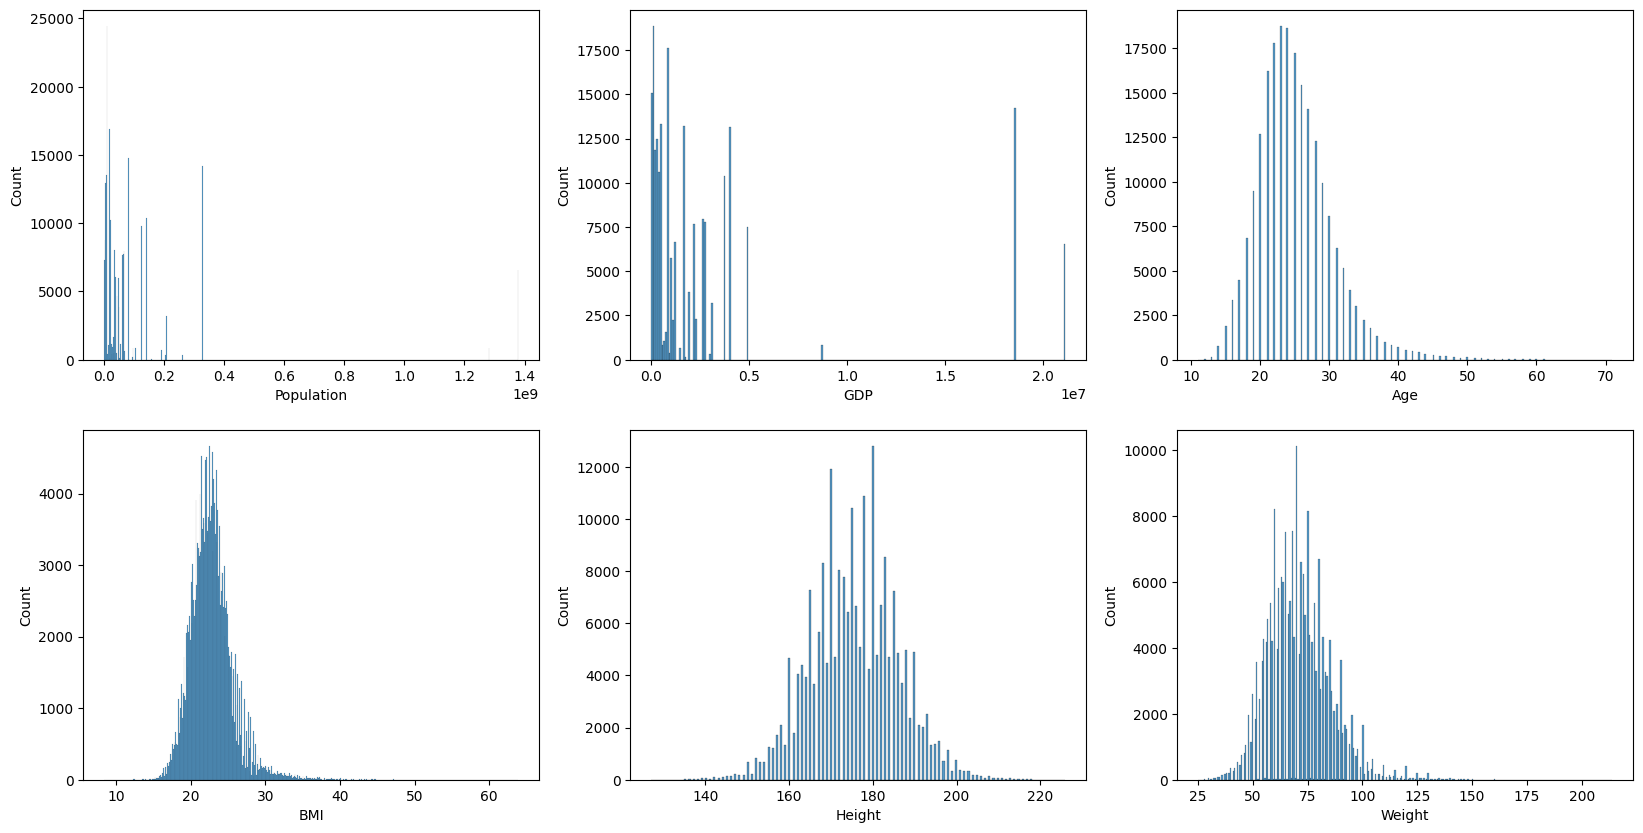

In [33]:
# Test for skewness in numerical variables: Population, GDP, Age BMI, Height, and Weight

def skewness():
    # Find skewness
    feature_names = ['Population', 'GDP', 'Age', 'BMI', 'Height', 'Weight']
    for i in range(len(feature_names)):
        print(f"{feature_names[i]} skew: {df_data[feature_names[i]].skew()}")
        
    # Create dist plots of each variable
    fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))
    for i, ax in zip(range(len(feature_names)), axes.flat):
        sns.histplot(df_data[feature_names[i]], ax=ax)
    plt.show()

skewness()

#### 使用对数变换校正偏度

由于特征的分布通常是倾斜的，对每个特征应用一个对数函数来缩放和规范化它们，如下所示。

In [34]:
# Use log transformation to scale BMI, weight, age features
pop_log = np.log(df_data['Population'])
gdp_log = np.log(df_data['GDP'])
bmi_log = np.log(df_data['BMI'])
weight_log = np.log(df_data['Weight'])
age_log = np.log(df_data['Age'])

log_features = [pop_log, gdp_log, age_log, bmi_log, df_data['Height'], weight_log]
feature_names = ['Population', 'GDP', 'Age', 'BMI', 'Height', 'Weight']

# Normalize log transformed data
def normalize(column):
    upper = column.max()
    lower = column.min()
    y = (column-lower)/(upper-lower)
    return y

normal_features = []
for i in range(len(log_features)):
    norm = normalize(log_features[i])
    normal_features.append(norm)

# Empty dataframe with transformed and scaled values
cont_feature_sub_df = pd.DataFrame(columns = feature_names)

#### 比较对数变换前后的偏度和分布

Population skew: 4.3533959074269974
Population log-transformed skew: -0.27849310670242794 

GDP skew: 2.4592817322309934
GDP log-transformed skew: -0.46672671409623284 

Age skew: 1.1317032613900933
Age log-transformed skew: 0.23774501777568732 

BMI skew: 1.3958107358054657
BMI log-transformed skew: 0.5687729537264307 

Height skew: 0.015056983449107931
Height log-transformed skew: 0.015056983449107284 

Weight skew: 0.7750496803678708
Weight log-transformed skew: -0.02391419048588856 



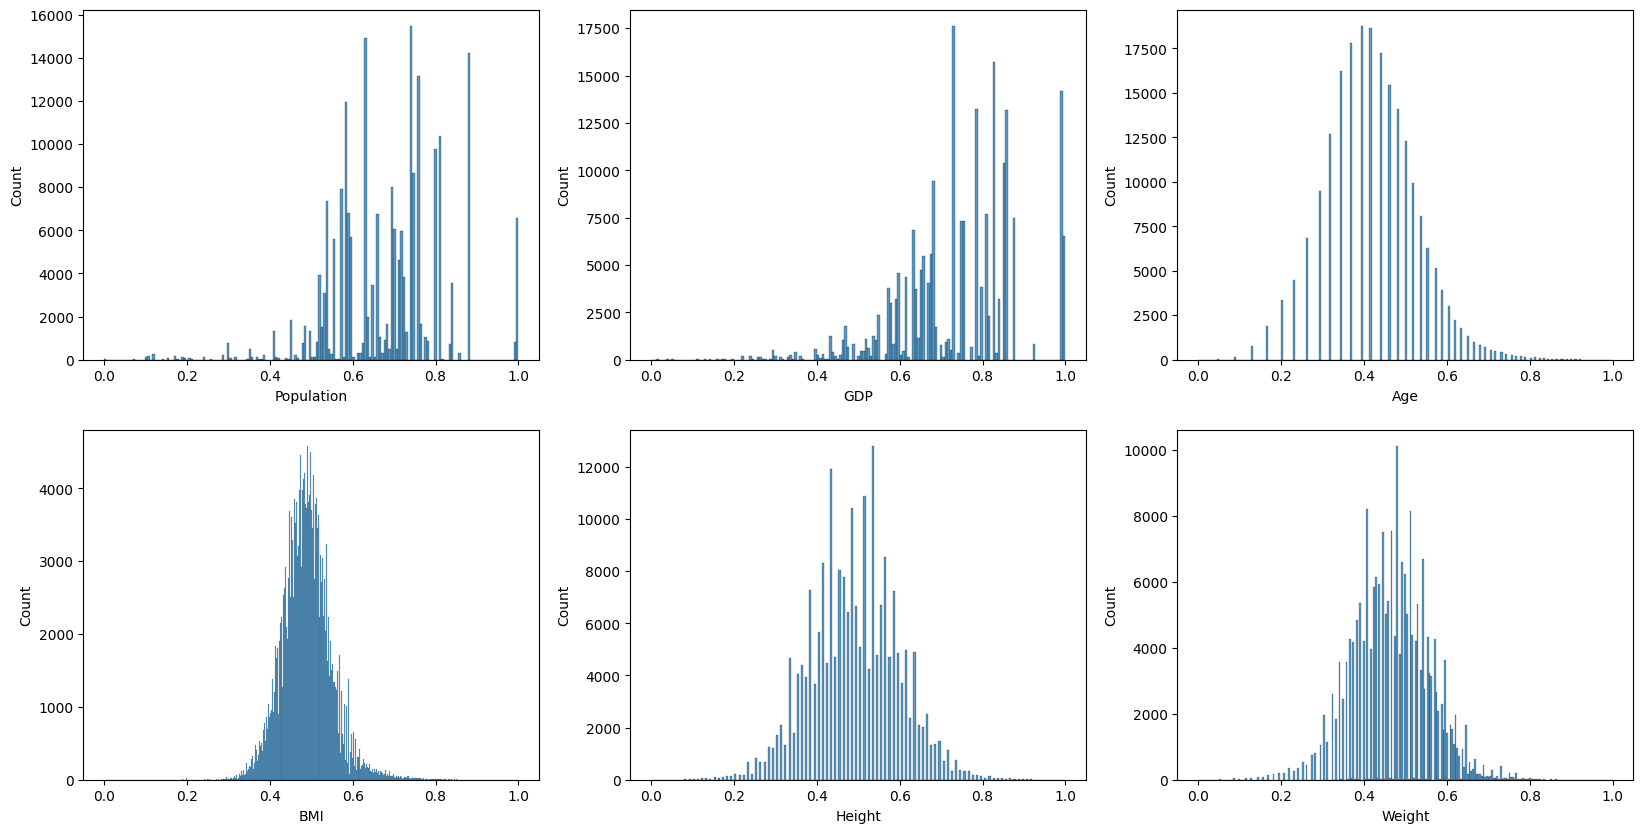

In [35]:
# Find and print new skewness
import scipy.stats

for i in range(len(normal_features)):
    print(f"{feature_names[i]} skew: {float(scipy.stats.skew(df_data[feature_names[i]]))}")
    print(f"{feature_names[i]} log-transformed skew: {float(scipy.stats.skew(normal_features[i]))} \n")
    # Add transformed values to dataframe
    cont_feature_sub_df[feature_names[i]] = normal_features[i]
    
# Create new dist plots with scaled and transformed variables
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))
for i, ax in zip(range(len(normal_features)), axes.flat):
    sns.histplot(normal_features[i], ax=ax, label=feature_names[i])
plt.show()

### 3.1.8 目标变量标签编码

因为的目标变量包含分类值（bronze, silver, gold, none），使用标签编码将的目标值转换为ML模型的数值，其中0代表金牌，1代表银牌，2代表铜牌，3代表没有奖牌。决定使用标签编码而不是单热编码来解释目标值中的不均匀权重，因为标签编码对更高的值更重要。例如，因为知道在现实生活中参加奥运会的运动员没有赢得奖牌的可能性更大，所以将最大值3赋给没有奖牌，这样这个值就更有分量了。

In [36]:
# Dictionary of numerical values corresponding to target categories
target_labels = {'Gold':0, 'Silver':1, 'Bronze':2, 'None':3}

# Use dictionary to transform each target value
def transform_medals(column):
    return target_labels[column]

# Apply transformation and create new dataframe with encoded target values
target_encoded_df = df_data
target_encoded_df["target"] = df_data["target"].apply(transform_medals)

### 3.1.9 用于模型测试的各种转换数据集

#### 原始数据集与目标变量编码
这个数据集主要用于数据探索而不是训练

In [37]:
target_encoded_df

,Country,Population,GDP,Sex,Age,Height,Weight,Year,BMI,Season,Sport,Event,target
0,Indonesia,260580739,3028000.0,M,20.0,162.0,57.0,1956,21.719250,Summer,Athletics,Athletics Men's 100 metres,3
1,Indonesia,260580739,3028000.0,M,22.0,160.0,56.0,1960,21.875000,Summer,Weightlifting,Weightlifting Men's Bantamweight,3
2,Indonesia,260580739,3028000.0,M,37.0,172.0,70.0,1960,23.661439,Summer,Sailing,Sailing Mixed Three Person Keelboat,3
3,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,22.309356,Summer,Cycling,Cycling Men's 100 kilometres Team Time Trial,3
4,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,22.309356,Summer,Cycling,"Cycling Men's Road Race, Individual",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
218042,New Zealand,4510327,174800.0,M,25.0,183.0,78.0,2016,23.291230,Summer,Hockey,Hockey Men's Hockey,3
218043,New Zealand,4510327,174800.0,F,18.0,159.0,58.0,2016,22.942130,Summer,Diving,Diving Women's Springboard,3
218044,New Zealand,4510327,174800.0,M,36.0,175.0,73.0,2016,23.836735,Summer,Shooting,"Shooting Men's Small-Bore Rifle, Prone, 50 metres",3
218045,New Zealand,4510327,174800.0,M,32.0,189.0,70.0,2016,19.596316,Summer,Rowing,Rowing Men's Lightweight Coxless Fours,3


#### 没有日志转换或规范化的数据集

In [38]:
# Merge dataset without log transformation
non_transf_features = df_data[['Population', 'GDP', 'Age', 'BMI', 'Height', 'Weight']]
combined_df = pd.concat([cat_feature_sub_df, non_transf_features, bin_feature_sub_df, target_encoded_df['target']], axis=1)
combined_df

,Country,Year,Sport,Event,Population,GDP,Age,BMI,Height,Weight,Sex_F,Sex_M,Season_Summer,Season_Winter,target
0,77,13,3,30,260580739,3028000.0,20.0,21.719250,162.0,57.0,0.0,1.0,1.0,0.0,3
1,77,14,54,540,260580739,3028000.0,22.0,21.875000,160.0,56.0,0.0,1.0,1.0,0.0,3
2,77,14,36,381,260580739,3028000.0,37.0,23.661439,172.0,70.0,0.0,1.0,1.0,0.0,3
3,77,14,14,201,260580739,3028000.0,18.0,22.309356,172.0,66.0,0.0,1.0,1.0,0.0,3
4,77,14,14,214,260580739,3028000.0,18.0,22.309356,172.0,66.0,0.0,1.0,1.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218042,123,34,24,310,4510327,174800.0,25.0,23.291230,183.0,78.0,0.0,1.0,1.0,0.0,3
218043,123,34,15,239,4510327,174800.0,18.0,22.942130,159.0,58.0,1.0,0.0,1.0,0.0,3
218044,123,34,37,404,4510327,174800.0,36.0,23.836735,175.0,73.0,0.0,1.0,1.0,0.0,3
218045,123,34,33,352,4510327,174800.0,32.0,19.596316,189.0,70.0,0.0,1.0,1.0,0.0,3


#### 具有日志转换和规范化的数据集

In [39]:
# Merge dataset with log transformation
df_log_transf = pd.concat([cat_feature_sub_df, cont_feature_sub_df, bin_feature_sub_df, target_encoded_df['target']], axis=1)
df_log_transf

,Country,Year,Sport,Event,Population,GDP,Age,BMI,Height,Weight,Sex_F,Sex_M,Season_Summer,Season_Winter,target
0,77,13,3,30,0.860060,0.836021,0.320593,0.469387,0.353535,0.383855,0.0,1.0,1.0,0.0,3
1,77,14,54,540,0.860060,0.836021,0.371704,0.472901,0.333333,0.375612,0.0,1.0,1.0,0.0,3
2,77,14,36,381,0.860060,0.836021,0.650489,0.511500,0.454545,0.479540,0.0,1.0,1.0,0.0,3
3,77,14,14,201,0.860060,0.836021,0.264093,0.482568,0.454545,0.452135,0.0,1.0,1.0,0.0,3
4,77,14,14,214,0.860060,0.836021,0.264093,0.482568,0.454545,0.452135,0.0,1.0,1.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218042,123,34,24,310,0.519408,0.595360,0.440255,0.503746,0.565657,0.529939,0.0,1.0,1.0,0.0,3
218043,123,34,15,239,0.519408,0.595360,0.264093,0.496320,0.323232,0.391955,1.0,0.0,1.0,0.0,3
218044,123,34,37,404,0.519408,0.595360,0.635797,0.515129,0.484848,0.499084,0.0,1.0,1.0,0.0,3
218045,123,34,33,352,0.519408,0.595360,0.572635,0.418813,0.626263,0.479540,0.0,1.0,1.0,0.0,3


## 3.2. 数据探索


### 3.2.1 数据集初步探索

下面的可视化展示了对数据集的初步探索。下面的图表显示了的样本按性别分布。该分布图表明，的数据样本中男性运动员明显多于女性运动员，男性运动员的数量（14万+）大约是女性运动员数量（7万+）的两倍。

Text(0.5, 1.0, 'Sex Distribution of Olympic Athletes')

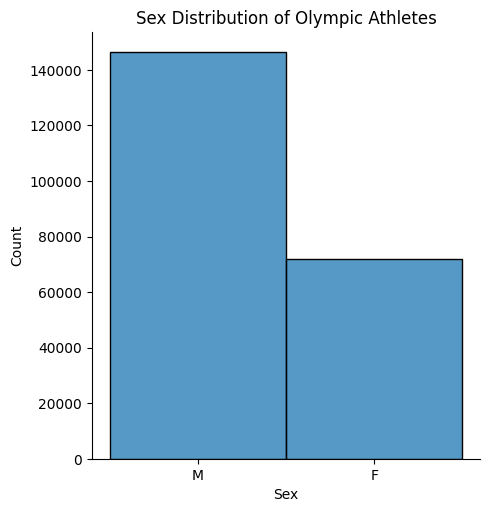

In [40]:
sns.displot(target_encoded_df, x="Sex")

#specify the title
title = "Sex Distribution of Olympic Athletes"

#set the title of the plot
plt.title(title)

下面的图表显示了的样本在奥运会季节的分布。该分布图表明，的数据样本中夏季运动员的数量明显多于冬季运动员，夏季运动员的数量（175,000+）是冬季运动员数量（40,000+）的三倍。这是有道理的，因为夏季奥运会的项目和项目也比冬季奥运会多，所以总的来说，参加夏季奥运会的运动员要比冬季奥运会多。

Text(0.5, 1.0, 'Season Distribution of Olympic Dataset')

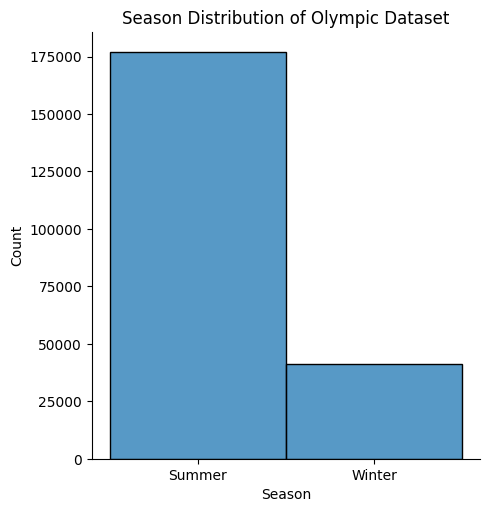

In [41]:
sns.displot(target_encoded_df, x="Season")

#specify the title
title = "Season Distribution of Olympic Dataset"

#set the title of the plot
plt.title(title)

下面的直方图显示了的样本按年龄分布。直方图显示，年龄分布呈正偏态，样本中大多数运动员集中在20-30岁左右，年龄越大，运动员数量向右急剧减少。这是有道理的，因为奥运会选手必须保持强壮和最佳的健康状态才能参加艰苦的训练和比赛，而年轻的年龄范围（20-30岁）通常是人们处于最佳健康状态的时候。

Text(0.5, 1.0, 'Age Distribution of Olympic Athletes')

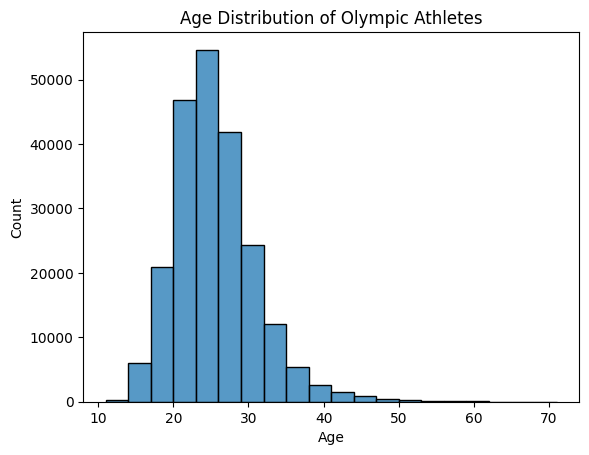

In [42]:
sns.histplot(target_encoded_df, x="Age", bins=20)

#specify the title
title = "Age Distribution of Olympic Athletes"

#set the title of the plot
plt.title(title)

下面的核密度图显示了运动员在年龄和BMI方面的分布。如图所示，“最密集”的区域由最小的内圈表示，这表明大多数女运动员（橙色表示）聚集在20岁出头（年龄），体重指数约为21。同样，大量男性运动员的身体质量指数在25左右，年龄在20岁出头。女性运动员的圆形更密集（紧密地聚集在一起），说明女性的年龄和bmi分布相对较小。相比之下，男性运动员的图密度较低（有更多的形状，分组距离更远），表明年龄/ bmi的分布更分散。

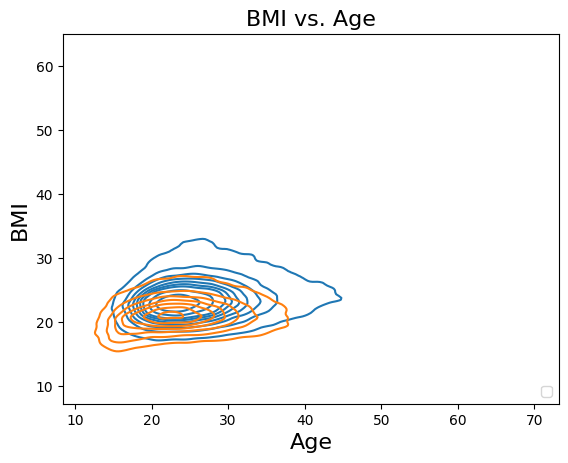

In [43]:
# Create and display the kernel density plot
graph = sns.kdeplot(x="Age", y="BMI", hue = "Sex", 
                        data = df_data)

# Specify the title
title = "BMI vs. Age"

# Set the title of the plot
graph.set_title(title, size = 16)

# Add labels to the axes  
graph.set_xlabel("Age", size = 16)
graph.set_ylabel("BMI", size = 16)

# Move the legend to lower right
plt.legend(loc="lower right")


In [44]:
def heatmap(dataframe, start_col, end_col, color):
    df_features = dataframe.iloc[:, start_col:end_col]
    
    # Find the correlation coefficient between each trait as a new dataframe (absolute value applied so all coefficients between 0 and 1)
    df_corr = df_features.corr().abs()
    
    # Set sizes of figure
    fig_dims = (10, 7)
    fig, ax = plt.subplots(figsize=fig_dims)
    
    # Create a blue heatmap of strengh of correlation
    viz = sns.heatmap(df_corr, vmin=0, vmax=1, linewidths=0.5, cmap=color, ax=ax)
    viz.set(title="Correlation between Variables")

#### 相关性热图（与奖牌类型相比较的特征）

下面的热图描述了每个变量之间的相关性有多强（如旁边的键所示，框中的蓝色越深，变量之间的相关性就越强）。相关性最强的变量包括身高、体重、GDP和人口。根据这张热图，GDP、身高和体重等特征似乎与目标变量（获得的奖牌类型）有更强的相关性。然而，每个单独变量和目标之间的相关性总体上似乎不是很强（由目标列的浅色显示）。

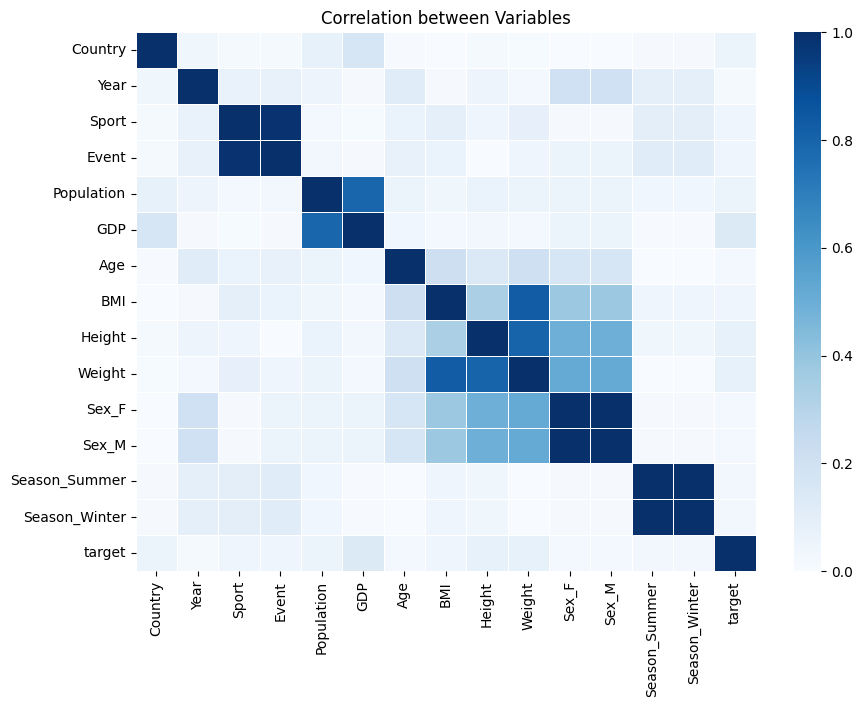

In [45]:
heatmap(combined_df, 0, 16, 'Blues')

### 3.2.2 数据探索按国家和奖牌总数排序

#### 创建新的数据df，按国家和奖牌总数排序

为了从更简洁的角度更好地理解和可视化的数据，决定创建另一个数据框架，将原始数据框架按国家分组，并查看每个国家获得的总奖牌、每个国家派出的运动员总数、每个国家运动员的年龄、体重、身高、BMI中位数以及每个国家最常见的运动、项目和季节等指标。能够将这些计算出的指标与其他列（如每个国家的GDP和人口）进行比较，以更好地了解这些变量如何相互影响。

In [46]:
# Function used to change medal type to number of medals (to sum by country after)
def change_target(medal):
    if medal == 0 or medal == 1 or medal == 2:
        medal = 1
    else:
        medal = 0
    return medal

In [47]:
# Count number of entries for each country to determine number of athletes and add to df_data
df_data['Number of Athletes'] = df_data.groupby('Country')['Country'].transform('count') 
df_data

,Country,Population,GDP,Sex,Age,Height,Weight,Year,BMI,Season,Sport,Event,target,Number of Athletes
0,Indonesia,260580739,3028000.0,M,20.0,162.0,57.0,1956,21.719250,Summer,Athletics,Athletics Men's 100 metres,3,334
1,Indonesia,260580739,3028000.0,M,22.0,160.0,56.0,1960,21.875000,Summer,Weightlifting,Weightlifting Men's Bantamweight,3,334
2,Indonesia,260580739,3028000.0,M,37.0,172.0,70.0,1960,23.661439,Summer,Sailing,Sailing Mixed Three Person Keelboat,3,334
3,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,22.309356,Summer,Cycling,Cycling Men's 100 kilometres Team Time Trial,3,334
4,Indonesia,260580739,3028000.0,M,18.0,172.0,66.0,1960,22.309356,Summer,Cycling,"Cycling Men's Road Race, Individual",3,334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218042,New Zealand,4510327,174800.0,M,25.0,183.0,78.0,2016,23.291230,Summer,Hockey,Hockey Men's Hockey,3,3880
218043,New Zealand,4510327,174800.0,F,18.0,159.0,58.0,2016,22.942130,Summer,Diving,Diving Women's Springboard,3,3880
218044,New Zealand,4510327,174800.0,M,36.0,175.0,73.0,2016,23.836735,Summer,Shooting,"Shooting Men's Small-Bore Rifle, Prone, 50 metres",3,3880
218045,New Zealand,4510327,174800.0,M,32.0,189.0,70.0,2016,19.596316,Summer,Rowing,Rowing Men's Lightweight Coxless Fours,3,3880


In [48]:
# Create df_summary grouped by country
df_summary = df_data.iloc[:, 0:14]
df_summary['GDP per Capita'] = df_summary['GDP']/df_summary['Population']

# Find total medals, median BMI, median Age, median Weight, most common event, most common sport, most common season, year with most athletes, number of athletes, GDP, GDP per capita, and Population for each country
df_summary['Total Medals'] = df_summary['target'].apply(change_target)
df_summary = df_summary.groupby('Country', as_index=False).agg({'Total Medals': 'sum', 'Population':lambda x: pd.Series.mode(x)[0],
                                                                'GDP':lambda x: pd.Series.mode(x)[0], 'Age': 'median', 'Height':'median','Weight':'median', 'Year':lambda x: pd.Series.mode(x)[0],
                                                                'BMI':'median', 'Season':lambda x: pd.Series.mode(x)[0], 'Sport':lambda x: pd.Series.mode(x)[0], 
                                                                'GDP per Capita':lambda x: pd.Series.mode(x)[0], 'Event':lambda x: pd.Series.mode(x)[0], 'Number of Athletes':lambda x: pd.Series.mode(x)[0]})
df_summary['Medals per Athlete'] = (df_summary['Total Medals']/df_summary['Number of Athletes'])
df_summary

,Country,Total Medals,Population,GDP,Age,Height,Weight,Year,BMI,Season,Sport,GDP per Capita,Event,Number of Athletes,Medals per Athlete
0,Afghanistan,2,34124811,64080.0,23.0,170.0,64.0,1960,22.128136,Summer,Wrestling,0.001878,Athletics Men's 100 metres,54,0.037037
1,Albania,0,3047987,33900.0,23.0,170.0,69.0,2008,23.087868,Summer,Weightlifting,0.011122,"Shooting Women's Sporting Pistol, 25 metres",57,0.000000
2,Algeria,15,40969443,609400.0,24.0,175.0,66.0,2016,21.971336,Summer,Athletics,0.014875,Handball Men's Handball,481,0.031185
3,American Samoa,0,51504,711.0,26.0,175.0,82.0,1988,26.595745,Summer,Athletics,0.013805,Athletics Men's 100 metres,21,0.000000
4,Andorra,0,85702,3327.0,22.0,173.0,71.0,2010,23.255019,Winter,Alpine Skiing,0.038821,Alpine Skiing Men's Giant Slalom,135,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,Venezuela,15,31304016,468600.0,24.0,173.0,69.0,2008,22.720438,Summer,Swimming,0.014969,"Cycling Men's Road Race, Individual",785,0.019108
185,Vietnam,4,96160163,594900.0,23.0,165.0,58.0,1980,20.831262,Summer,Swimming,0.006187,"Cycling Men's Road Race, Individual",182,0.021978
186,Yemen,0,28036829,73450.0,21.0,168.0,61.0,1988,21.773842,Summer,Athletics,0.002620,"Athletics Men's 1,500 metres",37,0.000000
187,Zambia,1,15972000,65170.0,23.0,175.0,67.0,1988,21.604938,Summer,Athletics,0.004080,Football Men's Football,128,0.007812


#### 从df_summary中创建包含前20个获奖国家的新数据框架

In [49]:
# Create df of top 20 countries with most medals
top_df = df_summary.nlargest(n=20, columns='Total Medals', keep='first')
top_df

,Country,Total Medals,Population,GDP,Age,Height,Weight,Year,BMI,Season,Sport,GDP per Capita,Event,Number of Athletes,Medals per Athlete
177,USA,4383,326625791,18560000.0,24.0,178.0,72.0,1992,22.720438,Summer,Athletics,0.056823,Ice Hockey Men's Ice Hockey,14214,0.308358
143,Russia,3610,142257519,3745000.0,25.0,176.0,70.0,1988,22.720438,Summer,Athletics,0.026325,Ice Hockey Men's Ice Hockey,10398,0.347182
63,Germany,3189,80594017,3979000.0,24.0,178.0,70.0,1972,22.530864,Summer,Athletics,0.049371,Ice Hockey Men's Ice Hockey,13183,0.241902
122,Netherlands,2832,17084719,870800.0,25.0,180.0,73.0,2016,22.460034,Summer,Swimming,0.050970,Hockey Men's Hockey,14916,0.189863
9,Australia,1210,23232413,1189000.0,24.0,177.0,71.0,2000,22.662709,Summer,Swimming,0.051178,Hockey Men's Hockey,6630,0.182504
31,Canada,1060,35623680,1674000.0,24.0,175.0,70.0,1988,22.656250,Summer,Athletics,0.046991,Ice Hockey Men's Ice Hockey,7966,0.133066
82,Italy,1060,62137802,2221000.0,25.0,175.0,70.0,1992,22.675737,Summer,Athletics,0.035743,Water Polo Men's Water Polo,7697,0.137716
37,China,1038,1379302771,21140000.0,23.0,172.0,65.0,2008,21.913806,Summer,Swimming,0.015327,Basketball Men's Basketball,6555,0.158352
176,UK,1031,64769452,2788000.0,25.0,175.0,70.0,2012,22.530864,Summer,Athletics,0.043045,Hockey Men's Hockey,7766,0.132758
60,France,987,67106161,2699000.0,25.0,175.0,69.0,1992,22.275310,Summer,Athletics,0.040220,Ice Hockey Men's Ice Hockey,7977,0.123731


#### 从df_summary中创建包含每个运动员获得奖牌前20名的国家的新数据框

In [50]:
# Create df with top 20 countries with largest medals per athlete ratio
medal_per_athlete_df = df_summary.nlargest(n=20, columns='Medals per Athlete', keep='first')
medal_per_athlete_df.reset_index(inplace=True)
medal_per_athlete_df

,index,Country,Total Medals,Population,GDP,Age,Height,Weight,Year,BMI,Season,Sport,GDP per Capita,Event,Number of Athletes,Medals per Athlete
0,143,Russia,3610,142257519,3745000.0,25.0,176.0,70.0,1988,22.720438,Summer,Athletics,0.026325,Ice Hockey Men's Ice Hockey,10398,0.347182
1,177,USA,4383,326625791,18560000.0,24.0,178.0,72.0,1992,22.720438,Summer,Athletics,0.056823,Ice Hockey Men's Ice Hockey,14214,0.308358
2,130,Pakistan,107,204924861,988200.0,25.0,174.0,70.0,1960,22.592987,Summer,Hockey,0.004822,Hockey Men's Hockey,366,0.292350
3,63,Germany,3189,80594017,3979000.0,24.0,178.0,70.0,1972,22.530864,Summer,Athletics,0.049371,Ice Hockey Men's Ice Hockey,13183,0.241902
4,150,Serbia,467,7111024,101800.0,24.0,180.0,75.0,1984,23.405654,Summer,Athletics,0.014316,Water Polo Men's Water Polo,2342,0.199402
5,84,Jamaica,154,2990561,25390.0,24.0,176.0,68.0,2016,21.877551,Summer,Athletics,0.008490,Athletics Men's 4 x 400 metres Relay,809,0.190358
6,122,Netherlands,2832,17084719,870800.0,25.0,180.0,73.0,2016,22.460034,Summer,Swimming,0.050970,Hockey Men's Hockey,14916,0.189863
7,9,Australia,1210,23232413,1189000.0,24.0,177.0,71.0,2000,22.662709,Summer,Swimming,0.051178,Hockey Men's Hockey,6630,0.182504
8,43,Cuba,394,11147407,132900.0,24.0,175.0,72.0,1980,23.306680,Summer,Athletics,0.011922,Baseball Men's Baseball,2210,0.178281
9,142,Romania,597,21529967,441000.0,24.0,173.0,67.0,1980,22.491349,Summer,Gymnastics,0.020483,Rowing Women's Coxed Eights,3477,0.171700


#### 按国家分组的数据框可视化

下面的散点图显示，运动员人数与获得的奖牌总数之间存在较强的正相关关系；换句话说，一个国家派出越多的运动员参加奥运会，这个国家就越有可能赢得更多的奖牌。这是有道理的，因为有更多的运动员参加比赛，自然意味着一个国家有更多的参与者，就更有可能赢得更多的奖牌。虽然每个点的大小代表人均GDP，但人均GDP与运动员数量/总奖牌数之间似乎没有很强的相关性；大多数获得奖牌最多的国家的人均国内生产总值既不太大也不太小。为了解释这种差异，并创建一个使各国之间具有可比性的指标，创建了“运动员人均奖牌数”这一列，通过将一个国家的总奖牌数除以该国的运动员总数来计算。

Text(0, 0.5, 'Total Medals')

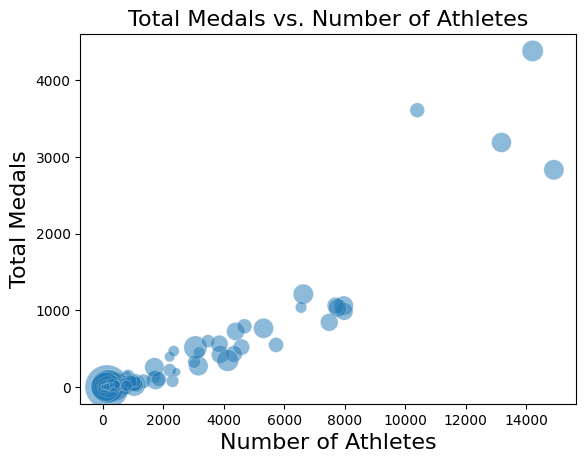

In [51]:
# Create and display the scatterplot
graph = sns.scatterplot(x="Number of Athletes", y="Total Medals", size = "GDP per Capita", sizes= (10, 1000), data = df_summary, alpha=.5, legend=False)

# Specify the title
title = "Total Medals vs. Number of Athletes"

# Set the title of the plot
graph.set_title(title, size = 16)

# Add labels to the axes  
graph.set_xlabel("Number of Athletes", size = 16)
graph.set_ylabel("Total Medals", size = 16)


#### 描绘各国特征之间相关性的热图（与运动员人均奖牌数相比较的特征）

下面的热图显示了按国家分组的数据框中每个变量之间的相关性有多强。从热图中可以看出，GDP与总奖牌数、运动员人数与总奖牌数、GDP与参加奥运会的运动员人数等变量之间存在着中等到强的相关性(这些变量之间不是由彼此推导出来的（例如，BMI是由体重和身高计算出来的）。此外，国内生产总值与运动员人均奖牌数有适度的相关性，这表明国内生产总值较高（较富裕）的国家更有可能赢得更多的奖牌。

In [ ]:

heatmap(df_summary, 0, 16, 'Reds')

KeyError: 'Value'

下面的散点图比较了一个国家的GDP和每个运动员的奖牌数。散点图的总体趋势显示出轻微的正相关，这意味着一个国家的GDP越高，该国每位运动员获得的奖牌就越多。然而，图表中也有许多数据点代表了GDP值较低但运动员人均奖牌数较高的国家，这就是为什么正相关性不那么强的原因。

Text(0, 0.5, 'Medals per Athlete')

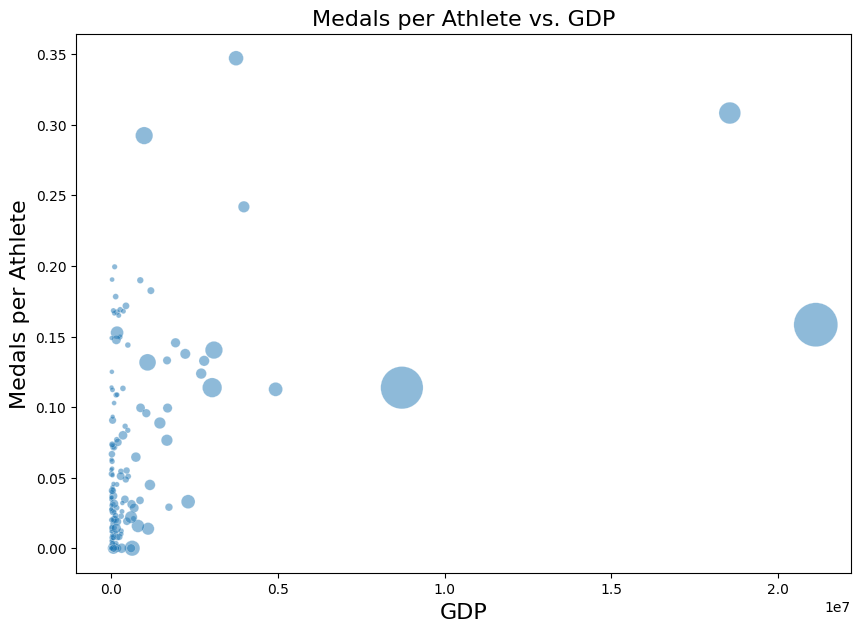

In [59]:
# Set sizes of figure
fig_dims = (10, 7)
fig, ax = plt.subplots(figsize=fig_dims)

# Create and display the scatterplot
graph = sns.scatterplot(x="GDP", y="Medals per Athlete", size = "Population", sizes= (10, 1000), data = df_summary, alpha=.5, ax=ax, legend=False)

# Specify the title
title = "Medals per Athlete vs. GDP"

# Set the title of the plot
graph.set_title(title, size = 16)

# Add labels to the axes  
graph.set_xlabel("GDP", size = 16)
graph.set_ylabel("Medals per Athlete", size = 16)

下面的条形图展示了获得奥运会奖牌最多的前20个国家以及每个国家获得的奖牌总数。从图中可以看出，总的来说，美国的奖牌数最多，达到4000 +枚，其次是俄罗斯（3500 +枚），然后是德国（3000 +枚）。

Text(0, 0.5, 'Total Medals')

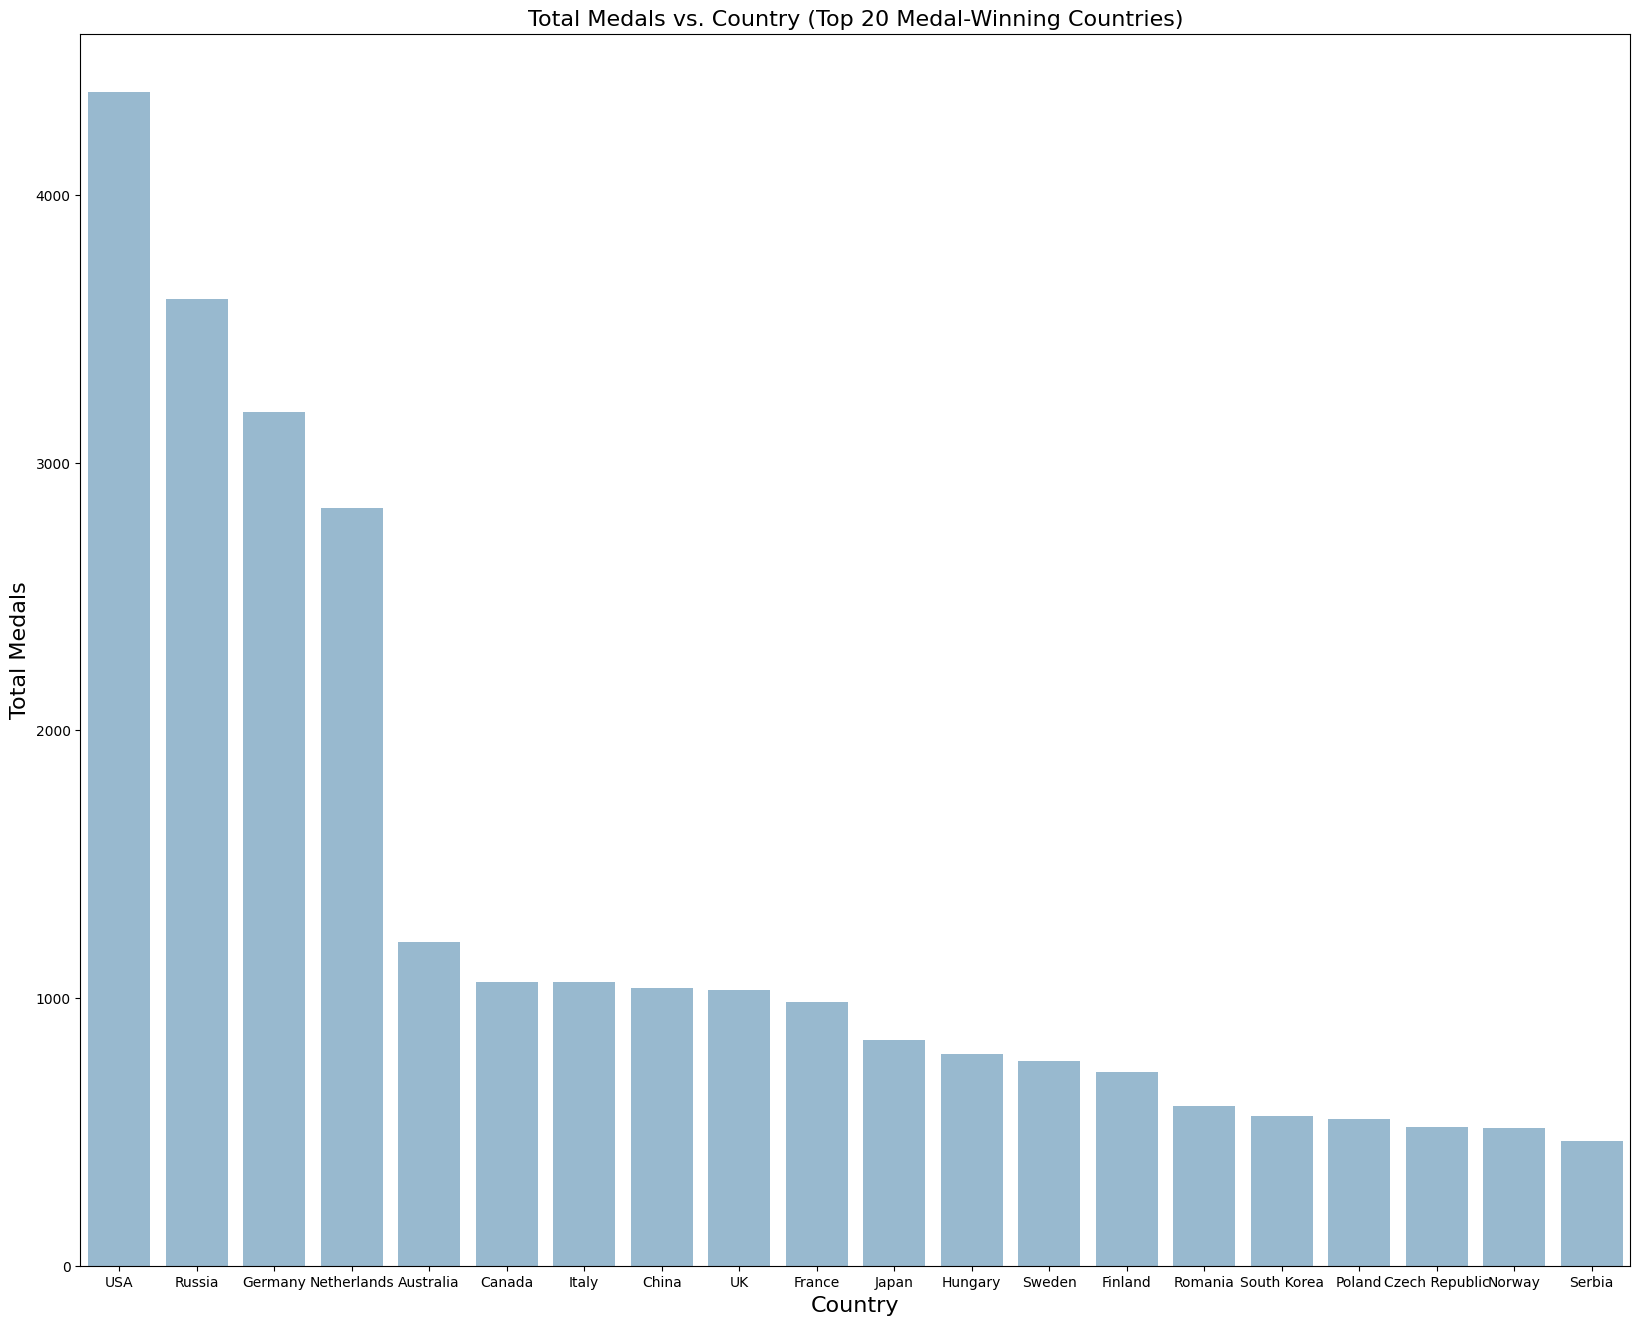

In [60]:
# Set sizes of figure
fig_dims = (20, 16)
fig, ax = plt.subplots(figsize=fig_dims)

# Create and display the bar plot
graph = sns.barplot(x="Country", y="Total Medals", data = top_df, alpha=.5, ax=ax)

# Specify the title
title = "Total Medals vs. Country (Top 20 Medal-Winning Countries)"

# Set the title of the plot
graph.set_title(title, size = 16)

# Add labels to the axes  
graph.set_xlabel("Country", size = 16)
graph.set_ylabel("Total Medals", size = 16)

为了将奖牌总数和运动员数量这两个指标放在一起，使每个国家获得的奖牌数量更具可比性（因为已经展示了参加奥运会的运动员数量与获得的奖牌总数直接相关），下面的条形图显示了奖牌数量排名前20的国家和每个国家每位运动员的奖牌数量。从图表中可以明显看出，总体而言，俄罗斯的人均奖牌数最高，约为0.34枚，美国以0.31枚紧随其后，巴基斯坦以0.29枚紧随其后。

Text(0, 0.5, 'Medals per Athlete')

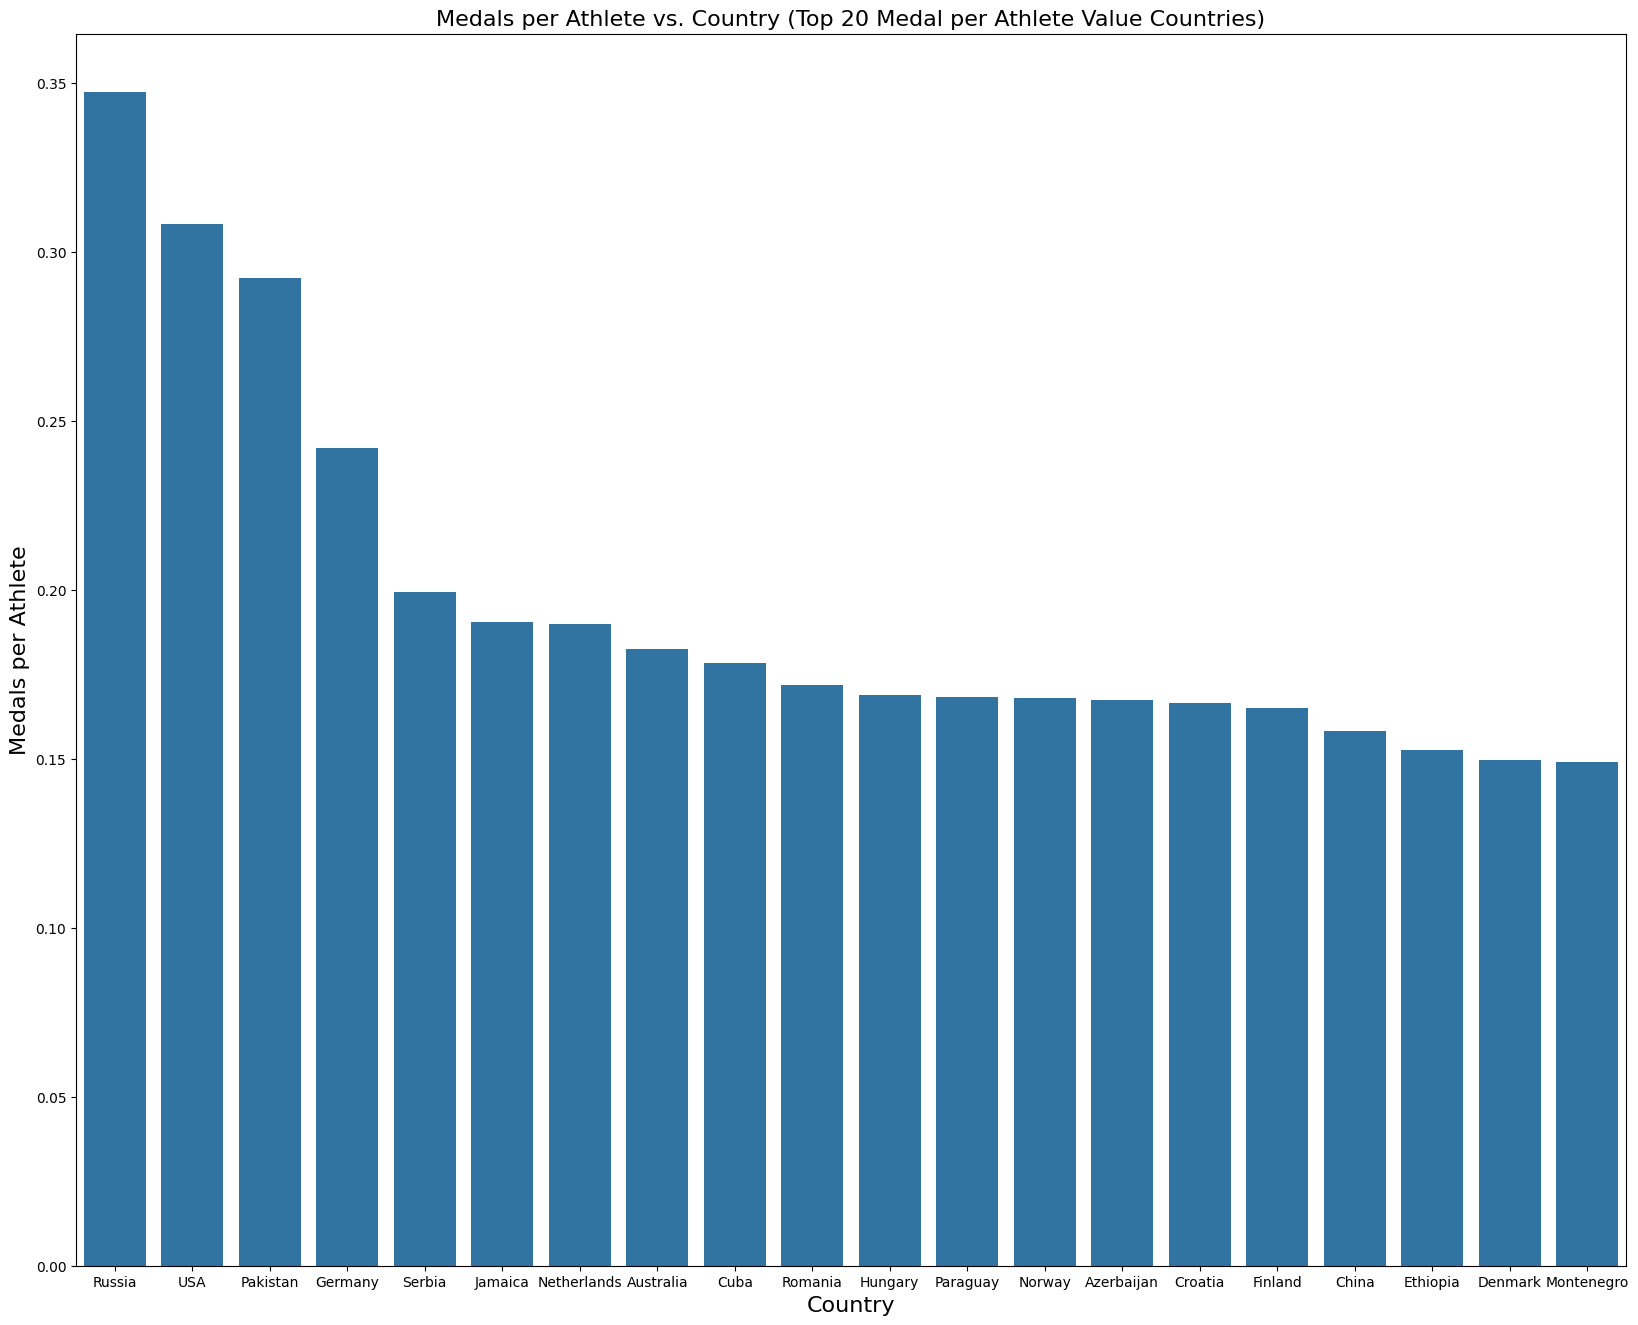

In [61]:
# Set sizes of figure
fig_dims = (20, 16)
fig, ax = plt.subplots(figsize=fig_dims)

# Create and display the bar plot
graph = sns.barplot(x="Country", y="Medals per Athlete", data = medal_per_athlete_df, ax=ax)

# Specify the title
title = "Medals per Athlete vs. Country (Top 20 Medal per Athlete Value Countries)"

# Set the title of the plot
graph.set_title(title, size = 16)

# Add labels to the axes  
graph.set_xlabel("Country", size = 16)
graph.set_ylabel("Medals per Athlete", size = 16)



### 3.3. Model Training


### 3.3.1 模型训练方法概述
#### 算法:
1. kNN Classifier
2. Decision Tree
3. Naive Bayes

#### 抽样方法:
1. Simple Random Sampling
2. SMOTE Sampling

#### 数据转换方法:
1. Log-transformations (see data wrangling)
2. Standard Scaler
3. Minmax Scaler

#### 评估指标:
1. Accuracy
2. Precision
3. Recall
4. F1-score

### 3.3.2 将训练模型定义为字典

In [67]:
# Import models: KNN, Naive Bayse, Decision Tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Store estimators as a dictionary for easy reference when training and testing
estimators = {'k-Nearest Neighbor': KNeighborsClassifier(), 'Gaussian Naive Bayes': GaussianNB(), 
              'Decision Tree': DecisionTreeClassifier()}

### 3.3.3 初始化评估度量数据框架

使用这个数据框架来存储不同的建模技术。这包括各种缩放方法、采样方法和超参数调优。对于性能指标，使用准确性、f1-score、召回率和精度。为不同的模型和优化技术找到了这些值。

在模型训练中，使用一种称为score的精度度量，它可以在sklearn库中以.score（）的形式获得。这通常用于确定模型准确性，因为它比较了训练集或测试集上的预测输出与实际输出之间的差异。本质上，特征被输入到模型中，并被训练来预测输出，即目标变量；然后将该预测输出与实际目标变量进行比较，并计算百分比精度。

除了准确性之外，还使用一些不同的常见分类性能评估指标：精度、召回率和f1-score。使用sk-learn的分类报告功能找到了所有这些。

精确度测量tp / (tp + fp)的比率，或真阳性率。通常，这个评估指标用于分类模型，因为它确定了给定模型不标记假阳性的能力。在项目的应用中，如果一名运动员被认定为奖牌获得者，但实际上并没有赢得比赛。这是衡量模型能力的一个重要指标，因为它很好地衡量了模型回答的问题的能力：能预测谁会赢吗？如果的准确率很低，可能会把失败者误认为是赢家。

回忆通常被理解为精确的反义词。它测量的是真负率，或tp / (tp + fn)。在项目的上下文中，选择了这个评估指标，因为它确定了能够正确识别奥运奖牌获得者的频率。

F1-score是准确率和召回率之间的加权平均值，计算公式为F1 = 2 *（准确率*召回率）/（准确率+召回率）。认为这个分数对于评估的模型性能很重要，因为它在某种意义上是“两全其美”。精准度可能高估了准确预测的奖牌预测指标的数量，而不是意外地将其归类为“无”，召回率过于依赖于不过度分配奖牌获得者，f1分数给了一个很好的中间点。

In [68]:
# Different forms of the three models to test
parameters = ['Base', 'Random Sampling', 'SMOTE Sampling', 'Min Max Scaler', 'Standard Scaler', 'Min Max Scaler (Log)', 'Standard Scaler (Log)', 'Feature Selection', 'Grid Search CV']

# Empty lists to add estimator models and model selection types as column labels
methods = []
models = []

# Add to column names using estimators dictionary
for parameter in parameters:
    for key, value in estimators.items():
        methods.append(parameter)
        models.append(key)

In [69]:
# Different performance metrics from classification report 

# Performance metrics for each target value (0: Gold, 1: Silver, 2: Bronze, 3: None)
report_keys = ['0', '1', '2', '3']

# Different metrics and grouping functions
report_agg = ['macro avg', 'weighted avg']
report_values = ['precision', 'recall', 'f1-score', 'support']

# Initialize empty lists to add metric names
column_idx = []
column_metric = []

# Add to list of row names
# For performance metrics based off of target value (0, 1, 2, 3)
for key in report_keys:
    for value in report_values:
        column_idx.append(key)
        column_metric.append(value)

# For accuracy performance metric
column_idx.append('all')
column_metric.append('accuracy')

# For aggregate performance metrics
for agg in report_agg:
    for value in report_values:
        column_idx.append(agg)
        column_metric.append(value)

#### 使用预定义的列和行初始化评估指标的空数据集

In [70]:
# Define columns and rows (indices) for empty dataframe
columns = [methods, models]
indices = [column_idx, column_metric]

# Fill dataframe with 0 values (to be replaced with actual performance metric values)
data = [ [0] * len(methods) for _ in range(len(column_idx))]

# Create dataframe to store evaluation metrics
performance = pd.DataFrame(data, columns = columns, index = indices)
performance

Base                                     \
                       k-Nearest Neighbor Gaussian Naive Bayes Decision Tree   
0            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
1            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
2            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
3            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
all          accuracy                   0                    0             0   
macro avg    precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
weighted avg precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   

                          Random Sampling                                     \
                       k-Nearest Neighbor Gaussian Naive Bayes Decision Tree   
0            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
1            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
2            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
3            precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
all          accuracy                   0                    0             0   
macro avg    precision                  0                    0             0   
             recall                     0                    0             0   
             f1-score                   0                    0             0   
             support                    0                    0             0   
weighted avg precision              

#### 定义函数将评估分数添加到性能数据框

In [71]:
from sklearn.metrics import classification_report

def metrics(method, estimator, model, predicted, y_test):
    """ method: scaling, sampling, hyperparameter tuning, etc
        estimator: different models (knn, decision tree, naive bayes)
        model: trained model from given method and estimator
        predicted: using model to run on test set and find predicitons
        y_test: actual values corresponding to predictions"""
    
    # Find predicted and expected outcomes of model
    expected = y_test
    
    # Calculate classification report corresponding to model
    report = classification_report(y_true=expected, y_pred=predicted, output_dict=True)
    
    # Initialize empty list to append and store evaluation matrix values
    data = []
    
    # Add in order of performance dataframe indices (0-3 -> accuracy -> aggregated metrics)
    # Append performance scores for target values (0, 1, 2, 3)
    for i in range(4):
        dct = report[str(i)]
        for metric, value in dct.items():
            data.append(value)
    
    # Append accuracy score
    data.append(report['accuracy'])
    
    # Append aggregated performance scores
    report_labels = ['macro avg', 'weighted avg']
    for label in report_labels:
        for metric, value in report[label].items():
            data.append(value)
    
    # From data list, add in each value to corresponding spot in predefined performance dataframe
    for i in range(len(data)):
        performance[method, estimator].iloc[i] = data[i]

### 3.3.4 初始模型训练：基线模型

In [72]:
# Split data into train and test sets, run algorithms, and return accuracy score

# Define features and target based on non-transformed, original (encoded) dataset
from sklearn.model_selection import train_test_split
features = combined_df.drop(["target"], axis=1)
target = combined_df["target"]

def base_model():
    # Create train and test sets
    X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=3000)
    y_train = np.ravel(y_train)
    y_test = np.ravel(y_test)
    
    # Using train and test sets, run through each of the three estimators
    for name, estimator in estimators.items():
        model = estimator.fit(X=X_train, y=y_train)
        accuracy = model.score(X_test, y_test)
        predicted = model.predict(X=X_test)
        print(f'{name}: \n\t Classification accuracy on the test data: {accuracy:.2%}\n')
        metrics('Base', name, model, predicted, y_test)

In [73]:
base_model()

k-Nearest Neighbor: 
	 Classification accuracy on the test data: 84.87%

Gaussian Naive Bayes: 
	 Classification accuracy on the test data: 82.59%

Decision Tree: 
	 Classification accuracy on the test data: 86.11%



### 3.3.5 测试数据采样方法

当然，的数据集并没有获得奖牌和非奖牌运动员的均匀分布。这可能会显著影响的结果，因此测试了两种不同类型的抽样，以解释目标值的不均匀分布，并确定导致最佳模型性能的方法。

#### 目标值分布

In [74]:
# Create pie chart of target value distribution
def piedist(df, title):
    """ df: dataframe (resampling method)
        title: name of resampling method, for pie chart title """
    target_labels = {0:'Gold', 1:'Silver', 2:'Bronze', 3:'None'}
    colors = {0:'goldenrod', 1:'silver', 2:'saddlebrown', 3:'rosybrown'}
    
    # Find counts for each target value
    df_target_unique = df['target'].value_counts()
    
    # Create labels for pie chart
    labels = []
    palette = []
    for index, row in zip(df_target_unique.index, df_target_unique):
        labels.append(f'{target_labels[index]}: {row}')
        palette.append(colors[index])

    # Create pie plot of target value distribution
    fig, ax = plt.subplots(figsize=(5,5))

    plt.pie(df_target_unique, labels=labels, autopct='%1.1f%%' , colors=palette)
    plt.title(f'Distribution of Target Value {title}', fontsize=15)

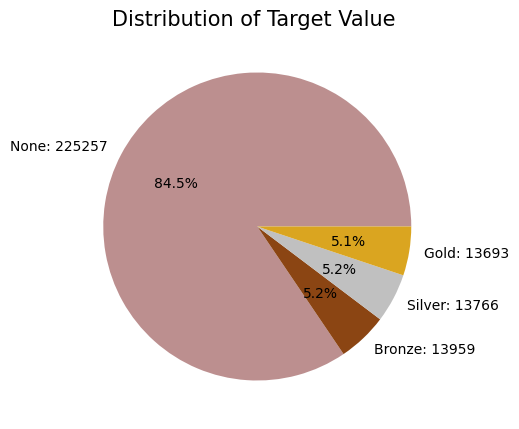

In [ ]:
piedist(combined_df, '')

在下面的单元格中，我们使用三种不同的算法（k近邻、高斯朴素贝叶斯和决策树）和两种不同的重采样技术（随机重采样和SMOTE重采样）训练了六个不同的模型。然后，我们比较了六种不同模型的精度。我们使用重采样是因为我们的目标变量是不平衡的。随机重采样是欠采样方法，使所有目标值有9800个样本；SMOTE重采样是少数类的过采样方法，使所有目标值有185547个样本。

### 3.3.6 简单随机抽样

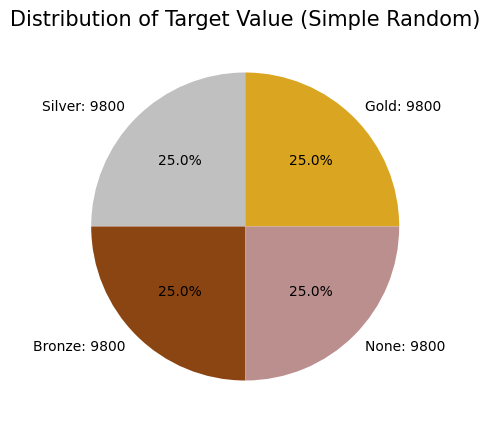

In [75]:
# Sets all target values to have a count of 9,800, since silver has the least samples
random_resampled_df = combined_df.groupby('target').apply(lambda x: x.sample(n=9800)).reset_index(drop = True)

# Create pie chart of distribution
piedist(random_resampled_df, title = '(Simple Random)')

### 3.3.7 SMOTE Sampling

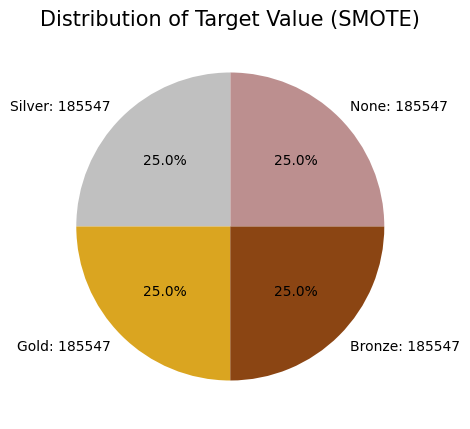

In [78]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# Oversampling minority target values
X = combined_df.drop(["target"], axis =1)
y = combined_df["target"]

sm = SMOTE(sampling_strategy = 'all', random_state=3000)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Create new dataframe of resampled values
df_target_smote = pd.DataFrame(y_resampled, columns =['target'])
smote_resampled_df = pd.concat([X_resampled, df_target_smote], axis=1)

# Create pie plot of target value distribution after smote resampling
piedist(smote_resampled_df, title = '(SMOTE)')

### 3.3.8 抽样方法比较

正如从下面的输出中看到的，对于kNN和决策树，SMOTE重采样数据比使用kNN和决策树分类器的随机重采样数据具有更高的精度。随机重采样数据和非随机重采样数据的kNN准确率从48.06%提高到88.45%。随机重采样数据和SMOTE重采样数据的决策树准确率由57.68%提高到86.38%。然而，高斯朴素贝叶斯在两种重采样技术之间差异不大，总体而言，该模型的准确率远低于kNN和Decision Tree，平均准确率低于30%。

In [79]:
# Define dictionary of sampling methods for easy use later
sampling_techniques = {"Random Sampling" : random_resampled_df, 
                       "SMOTE Sampling" : smote_resampled_df}


def best_sampling(): 
    # Loop through sampling methods
    for sampling_name, df in sampling_techniques.items():
        
        # Redefine feature and target for each resampled dataset
        features = df.drop(["target"], axis=1)
        target = df["target"]
        
        # Split into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=3000)
        y_train = np.ravel(y_train)
        y_test = np.ravel(y_test)
    
        # Train and return accuracy score, add to performance metrics dataframe
        for name, estimator in estimators.items():
            model = estimator.fit(X=X_train, y=y_train)
            accuracy = model.score(X_test, y_test)
            print(f'{name}: \n\t Classification accuracy on the test data with {sampling_name}: {accuracy:.2%}\n')
            predicted = model.predict(X=X_test)
            metrics(sampling_name, name, model, predicted, y_test)

In [80]:
best_sampling()

k-Nearest Neighbor: 
	 Classification accuracy on the test data with Random Sampling: 50.11%

Gaussian Naive Bayes: 
	 Classification accuracy on the test data with Random Sampling: 28.29%

Decision Tree: 
	 Classification accuracy on the test data with Random Sampling: 60.06%

k-Nearest Neighbor: 
	 Classification accuracy on the test data with SMOTE Sampling: 88.45%

Gaussian Naive Bayes: 
	 Classification accuracy on the test data with SMOTE Sampling: 28.40%

Decision Tree: 
	 Classification accuracy on the test data with SMOTE Sampling: 86.80%



In [81]:
# SMOTE resampled dataset without log transformations
features = smote_resampled_df.drop(["target"], axis=1)
target = smote_resampled_df["target"]

### 3.3.9 数据变换


除了对数变换，还想使用标准标量和最小最大标量，看看它们是否能更有效地校正原始数据集中的值分布。对于这一部分，比较了标量器在对数转换数据和原始特征（没有转换）上的性能。

In [82]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define tests to perform
# Scaling before log and normalized transformations
scalers = {"Min Max Scaler" : MinMaxScaler(), "Standard Scaler" : StandardScaler()}
# Scaling after log and normalized transformations
scalers_log = {"Min Max Scaler (Log)": MinMaxScaler(), "Standard Scaler (Log)": StandardScaler()}

In [83]:
def best_preprocessing(scalers_dict, features, target): 
    """ scalers_dict: either scalers or scalers log for scaling methods to test
        features: predefined features dataframe (from SMOTE resampling)
        target: predefined target series (from SMOTE resampling)
    """
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=3000)
    
    # Loop through and test min max and standard scaler
    for scaling_name, scaling_method in scalers_dict.items():
        
        # Define, fit, and test scaling method
        scaler = scaling_method
        scaler.fit(X_train) 
        X_train_scaled = scaler.transform(X_train) 
        X_test_scaled = scaler.transform(X_test)
        
        # Use trained scaler to test the three models
        for name, estimator in estimators.items():
            model = estimator.fit(X=X_train_scaled, y=y_train)
            accuracy_train = model.score(X_train_scaled, y_train)
            accuracy_test = model.score(X_test_scaled, y_test)
            
            # Add performance metrics to performance dataframe
            predicted = model.predict(X=X_test)
            metrics(scaling_name, name, model, predicted, y_test)
            
            # Return accuracy scores of different scaling methods
            print(f'{name}:')
            print(f'\t Classification accuracy on the training data with {scaling_name}: {accuracy_train:.2%}')
            print(f'\n\t Classification accuracy on the test data with {scaling_name}: {accuracy_test:.2%}\n')
            continue

### 3.3.10 测试没有对数转换的标量

在下一个单元格中，使用三种不同的算法（k-Nearest Neighbors，高斯朴素贝叶斯和决策树）和两种不同的缩放技术（Min Max Scaler和Standard Scaler）训练了六个不同的模型，并且已经使用SMOTE对数据进行了重新采样，因为SMOTE比随机重新采样具有更高的精度。最小最大标度器对kNN的准确度略高于标准标度器（84.83% ~ 83.44%）。使用最小最大标量和标准标量，朴素贝叶斯的准确率相同，为32.05%。Min Max Scaler和Standard Scaler的决策树准确率基本相同，但Min Max Scaler略高（86.45% ~ 86.38%）。kNN和朴素贝叶斯（对于最小最大标量和标准标量）没有显示过拟合的迹象；然而，对于两种缩放方法，决策树表明模型可能是过拟合的。这是因为决策树分类器的训练数据的准确率为99.9%，而测试数据的准确率仅为86%左右；这表明，对于所拥有的信息量来说，构建的决策树模型过于复杂，并且过于接近的训练集的特殊性。

In [84]:
best_preprocessing(scalers, features, target)

k-Nearest Neighbor:
	 Classification accuracy on the training data with Min Max Scaler: 89.83%

	 Classification accuracy on the test data with Min Max Scaler: 84.77%

Gaussian Naive Bayes:
	 Classification accuracy on the training data with Min Max Scaler: 32.20%

	 Classification accuracy on the test data with Min Max Scaler: 32.13%

Decision Tree:
	 Classification accuracy on the training data with Min Max Scaler: 99.95%

	 Classification accuracy on the test data with Min Max Scaler: 86.82%

k-Nearest Neighbor:
	 Classification accuracy on the training data with Standard Scaler: 88.76%

	 Classification accuracy on the test data with Standard Scaler: 83.47%

Gaussian Naive Bayes:
	 Classification accuracy on the training data with Standard Scaler: 32.20%

	 Classification accuracy on the test data with Standard Scaler: 32.13%

Decision Tree:
	 Classification accuracy on the training data with Standard Scaler: 99.95%

	 Classification accuracy on the test data with Standard Scaler: 

### 3.3.11 用对数变换测试标量

这里使用的数据已经使用对数转换进行了转换，以防止偏度。偏性存在于的连续数值变量中，因此在使用对数变换时，使这些特征更符合正态分布。在下一个单元格中，使用三种不同的算法（k-Nearest Neighbors，高斯朴素贝叶斯和决策树）和两种不同的缩放技术（Min Max Scaler和Standard Scaler）训练了六个不同的模型，并且已经使用SMOTE对数据进行了重新采样，因为SMOTE比随机重新采样具有更高的精度。最小最大标度器对kNN的准确度略高于标准标度器（85.61% ~ 84.44%）。使用最小最大标量和标准标量，朴素贝叶斯的准确率相同，为84.96%。Min Max Scaler和Standard Scaler的决策树准确率基本相同，但Min Max Scaler略高（86.39% ~ 86.34%）。最小最大标量和标准标量的kNN和朴素贝叶斯都没有显示出过拟合的迹象，然而，使用两种缩放方法的决策树表明模型可能是过拟合的。这是因为Decision Tree分类器的训练数据的准确率为99.9%，而测试数据的准确率仅为86%左右。

In [86]:
# Define features and target dataframes from previous, log-transformed dataset
features = df_log_transf.drop(["target"], axis=1)
target = df_log_transf["target"]

# Find best preprocessing (scaler vs minmax of log-transformed data)
best_preprocessing(scalers_log, features, target)

k-Nearest Neighbor:
	 Classification accuracy on the training data with Min Max Scaler (Log): 89.84%

	 Classification accuracy on the test data with Min Max Scaler (Log): 85.52%

Gaussian Naive Bayes:
	 Classification accuracy on the training data with Min Max Scaler (Log): 84.93%

	 Classification accuracy on the test data with Min Max Scaler (Log): 84.86%

Decision Tree:
	 Classification accuracy on the training data with Min Max Scaler (Log): 99.99%

	 Classification accuracy on the test data with Min Max Scaler (Log): 86.07%

k-Nearest Neighbor:
	 Classification accuracy on the training data with Standard Scaler (Log): 88.64%

	 Classification accuracy on the test data with Standard Scaler (Log): 84.36%

Gaussian Naive Bayes:
	 Classification accuracy on the training data with Standard Scaler (Log): 84.93%

	 Classification accuracy on the test data with Standard Scaler (Log): 84.86%

Decision Tree:
	 Classification accuracy on the training data with Standard Scaler (Log): 99.99%


### 3.3.12 特征选择：递归特征消除

In [85]:
# Define features and target for feature selection and hyperparameter tuning
features = smote_resampled_df.drop(["target"], axis=1)
target = smote_resampled_df["target"]

In [87]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor 

def RFE_feature_selection(estimator, n):
    """ estimator: define which modeling technique (kNN, tree, naive bayes),
        n: define number of features to select """
    method = estimators[estimator]
    X_train, X_test, y_train, y_test = train_test_split(features, target, random_state = 3000)
    
    # Get the most important features using RFE
    important_features = RFE(DecisionTreeClassifier(random_state = 3000), n_features_to_select = n)
    
    # Fit the RFE selector to the training data 
    important_features.fit(X_train, y_train)
    
    # Transform training and testing sets so that only the important selected features remain 
    X_train_selected = important_features.transform(X_train)
    X_test_selected = important_features.transform(X_test)
    
    # Apply method to the training data 
    model = method.fit(X=X_train_selected, y=y_train)
    
    print("Selected features after RFE: ")
    
    # Iterates through the number of columns in the df 
    for i in range(len(features.columns)): 
        
        # If the value corresponding with the column of the feature is true, the feature was used in the model
        if (important_features.support_[i] == True): 
            print("\t", features.columns[i])
            
    # Prints accuracy for the model on the training and testing sets 
    print("\n" + "Performance with selected features: ")
    print("\t" + "Accuracy for the training set: ", model.score(X_train_selected, y_train))
    print("\t" + "Accuracy for the testing set: ", model.score(X_test_selected, y_test))
    
    # Evaluate performance metrics and add to performance dataframe
    predicted = model.predict(X=X_test_selected)
    metrics('Feature Selection', estimator, model, predicted, y_test)

    

#### 用kNN分类器进行特征选择
n-values we tried: 4, 5, 6 7, 8, 9, 10

利用递归特征消去（RFE）确定了三种不同分类模型的最重要特征。对于kNN分类器，在国家、年份、事件、GDP、年龄、BMI、身高和体重这8个特征上获得了最高的准确率。在测试集上的准确率约为88.29%，模型不存在过拟合现象。这表明的模型中最重要的8个特征是上面列出的特征，这比没有特征选择的kNN模型产生更高的精度。

In [88]:
RFE_feature_selection('k-Nearest Neighbor', 8)

Selected features after RFE: 
	 Country
	 Year
	 Event
	 GDP
	 Age
	 BMI
	 Height
	 Weight

Performance with selected features: 
	Accuracy for the training set:  0.9326321582535848
	Accuracy for the testing set:  0.90165468153801


#### 基于决策树分类器的特征选择
n-values we tried: 4, 5, 6, 7, 8, 9, 10

对于决策树分类器，获得了9个特征的最高准确率，这9个特征包括国家、年份、运动、事件、GDP、年龄、BMI、身高和体重。在测试集上的准确率约为86.09%，而在训练集上的准确率接近100%，表明模型是过拟合的。RFE特征选择表明，最重要的9个特征是上面列出的特征，但与没有特征选择的数据相比，模型的准确率没有明显提高。

In [89]:
RFE_feature_selection('Decision Tree', 9)

Selected features after RFE: 
	 Country
	 Year
	 Sport
	 Event
	 GDP
	 Age
	 BMI
	 Height
	 Weight

Performance with selected features: 
	Accuracy for the training set:  0.9999388510104871
	Accuracy for the testing set:  0.8564719694746111


#### 朴素贝叶斯分类器的特征选择
n-values tried: 3, 4, 5, 6, 7, 8, 9

对于朴素贝叶斯分类器，在Year， Event, Age， BMI和Height这5个特征上获得了最高的准确率。在测试集上的准确率约为30.66%，模型不存在过拟合现象。这表明使用朴素贝叶斯的模型中最重要的5个特征是上面列出的特征，这比没有特征选择的模型产生略高的精度（不到1%）。

In [ ]:
RFE_feature_selection('Gaussian Naive Bayes', 5)

Selected features after RFE: 
	 Year
	 Event
	 GDP
	 Age
	 BMI

Performance with selected features: 
	Accuracy for the training set:  0.2829020481790429
	Accuracy for the testing set:  0.28090137043465907


## 3.4. 模型优化


使用网格搜索来超参数调整的三种算法，kNN，决策树和朴素贝叶斯。超参数调整允许通过查看最适合算法的参数来优化的模型。希望获得最高的精度，同时避免模型的过拟合或欠拟合。

In [90]:
# Define features and target for feature selection
features = smote_resampled_df.drop(["target"], axis=1)
target = smote_resampled_df["target"]

### 3.4.1 使用GridSearch进行超参数调优

In [91]:
from sklearn.model_selection import GridSearchCV

def grid_search(estimator, param_grid):
    """ estimator: model to test with (knn, tree, naive bayes)
        param_grid: dictionary of different parameters and values to testa nd compare"""
    # Use grid search to find best parameters
    method = estimators[estimator]
    grid_search = GridSearchCV(method, param_grid, cv=5)
    
    # Split into train and test sets, fit with grid search
    X_train, X_test, y_train, y_test = train_test_split(features, target, random_state = 3000)
    grid_search.fit(X=X_train, y=y_train)
    
    # Print resulting best parameters and evaluation metrics
    print("Best parameters: ", grid_search.best_params_)
    
    #print("Best cross-validation score: ", grid_search.best_score_)
    print("Test set score: ", grid_search.score(X_test, y_test))
    
    # Evaluate performance metrics and add to performance dataframe
    predicted = grid_search.predict(X=X_test)
    metrics('Grid Search CV', estimator, grid_search, predicted, y_test)


#### kNN分类器的GridSearch

对于kNN，测试了参数n_neighbors、weights和metric，以便找到产生最准确的kNN测试集分数的参数的正确组合。准确度最高的是度量为曼哈顿，1个邻居，权重为均匀，准确度为93.45%。

In [92]:
# Hyperparameters to test
param_grid = {"n_neighbors":[1, 5, 15, 25, 55], "weights":["uniform", "distance"], "metric":["euclidean", "manhattan", "minkowski"]}

grid_search('k-Nearest Neighbor', param_grid)

Best parameters:  {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Test set score:  0.9339897707858387


#### 决策树分类器的GridSearch

对于决策树模型，测试了参数标准max_depth和min_samples_leaf，以便确定产生最高测试集精度的最佳参数。结果是作为熵的标准，max_depth为55，min_samples_leaf为1，这给的测试集的准确率得分为86.75%。

In [ ]:
# Hyperparameters to test
param_grid = {"criterion":["gini", "entropy"], "max_depth":[5, 11, 15, 25, 35, 55], "min_samples_leaf":[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

grid_search('Decision Tree', param_grid)

Best parameters:  {'criterion': 'entropy', 'max_depth': 55, 'min_samples_leaf': 1}
Test set score:  0.8674675419166034


C:\Users\feiyu\anaconda3\lib\site-packages\pandas\core\indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


#### 朴素贝叶斯分类器的GridSearch

对于朴素贝叶斯分类器，测试了参数var_smoothing，看看哪个值产生最准确的模型。当var_smoothing = 0.019时，测试集得分为29.60%。

In [ ]:
# Hyperparameters to test
param_grid = {'var_smoothing': np.logspace(0,-9, num=100)}

grid_search('Gaussian Naive Bayes', param_grid)

Best parameters:  {'var_smoothing': 0.01873817422860384}
Test set score:  0.29601664268352496


C:\Users\feiyu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\feiyu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\feiyu\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\feiyu\anaconda3\lib\site-packages\pandas\core\

## 3.5. 模型测试

### 3.5.1 对比出最佳模型

In [ ]:
performance

Base                                     \
                       k-Nearest Neighbor Gaussian Naive Bayes Decision Tree   
0            precision           0.452998             0.053008      0.549060   
             recall              0.396735             0.031583      0.569908   
             f1-score            0.423004             0.039582      0.559290   
             support          2818.000000          2818.000000   2818.000000   
1            precision           0.336095             0.000000      0.456111   
             recall              0.218546             0.000000      0.519815   
             f1-score            0.264864             0.000000      0.485884   
             support          2599.000000          2599.000000   2599.000000   
2            precision           0.354732             0.000000      0.436707   
             recall              0.201352             0.000000      0.478212   
             f1-score            0.256890             0.000000      0.456518   
             support          2662.000000          2662.000000   2662.000000   
3            precision           0.906148             0.851892      0.938963   
             recall              0.953180             0.969311      0.924343   
             f1-score            0.929069             0.906816      0.931595   
             support         46433.000000         46433.000000  46433.000000   
all          accuracy            0.852675             0.827286      0.864947   
macro avg    precision           0.512493             0.226225      0.595210   
             recall              0.442453             0.250223      0.623069   
             f1-score            0.468457             0.236599      0.608322   
             support         54512.000000         54512.000000  54512.000000   
weighted avg precision           0.828616             0.728377      0.871259   
             recall              0.852675             0.827286      0.864947   
             f1-score            0.838416             0.774467      0.867899   
             support         54512.000000         54512.000000  54512.000000   

                          Random Sampling                                     \
                       k-Nearest Neighbor Gaussian Naive Bayes Decision Tree   
0            precision           0.473999             0.392956      0.620392   
             recall              0.604745             0.228790      0.636108   
             f1-score            0.531449             0.289199      0.628152   
             support          2487.000000          2487.000000   2487.000000   
1            precision           0.443400             0.000000      0.547983   
             recall              0.474638             0.000000      0.563205   
             f1-score            0.458487             0.000000      0.555489   
             support          2484.000000          2484.000000   2484.000000   
2            precision           0.453237             0.000000      0.553055   
             recall              0.417910             0.000000      0.570481   
             f1-score            0.434858             0.000000      0.561633   
             support          2412.000000          2412.000000   2412.000000   
3            precision           0.653670             0.265685      0.598008   
             recall              0.471659             0.918080      0.546545   
             f1-score            0.547945             0.412109      0.571120   
             support          2417.000000          2417.000000   2417.000000   
all          accuracy            0.492959             0.284490      0.579388   
macro avg    precision           0.506077             0.164660      0.579859   
             recall              0.492238             0.286717      0.579085   
             f1-score            0.493185             0.175327      0.579098   
             support          9800.000000          9800.000000   9800.000000   
weighted avg precision           0.5

In [93]:
# Save evaluation metrics dataframe as csv
performance.to_csv('model_evaluation.csv')

#### 最佳表现模型：

为了找到性能最好的模型，在性能数据框架中对每个模型的性能取平均值。发现三个最高的平均值属于网格搜索kNN（平均分：93.45%），SMOTE采样kNN（88.54%）和超参数调谐kNN（88.36%）。一般来说，kNN估计器的性能最好。

In [ ]:
# Define subset of original dataframe without support metric value
no_support = []
for row in performance.index:
    if row[1] != 'support':
        no_support.append(row)
final_vals = performance.loc[no_support]

# Find mean of each model using the metric scores and sort in descending order
means = final_vals.mean(axis=0)
means.sort_values(ascending=False)

Grid Search CV         k-Nearest Neighbor      0.934482
SMOTE Sampling         k-Nearest Neighbor      0.885428
Feature Selection      k-Nearest Neighbor      0.883600
Grid Search CV         Decision Tree           0.867675
SMOTE Sampling         Decision Tree           0.865906
Feature Selection      Decision Tree           0.861213
Base                   Decision Tree           0.663266
Random Sampling        Decision Tree           0.579380
Base                   k-Nearest Neighbor      0.552074
Random Sampling        k-Nearest Neighbor      0.496953
Standard Scaler (Log)  k-Nearest Neighbor      0.356353
Base                   Gaussian Naive Bayes    0.353824
Min Max Scaler (Log)   k-Nearest Neighbor      0.351436
                       Decision Tree           0.344663
Standard Scaler (Log)  Gaussian Naive Bayes    0.337402
Min Max Scaler (Log)   Gaussian Naive Bayes    0.335719
Standard Scaler (Log)  Decision Tree           0.309593
Feature Selection      Gaussian Naive Bayes    0

### 总结

比较了k近邻算法、朴素贝叶斯算法和决策树算法。使用了两种重采样技术（随机重采样和SMOTE）和三种数据转换技术（对数变换、最小最大缩放和标准缩放）。然后在所有模型上实现特征选择和超参数调优。使用上述方法的各种组合，总共有27个模型。
一般来说，预测模型应该使用的算法是kNN，因为它比朴素贝叶斯和决策树表现得更好。此外，决策树表示过拟合，所以kNN将是最好的选择。

性能最好的模型是带SMOTE采样的kNN网格搜索，不带特征选择。第二好的性能是使用kNN SMOTE采样，没有特征选择也没有超参数调优。总的来说，为了获得奥运会奖牌结果的最佳准确性，最好在所有特征上使用kNN算法（因为特征选择没有显示出显着差异）。

数据集中的特征可以用来预测应用的算法所获得的奖牌类型的目标变量。的模型在预测奥运会运动员获得的奖牌类型方面具有相对较高的准确性。有些特征似乎比其他特征更重要，比如国家、年份、赛事、GDP、年龄和BMI，但总的来说，的模型在基于数据集中的特征预测获得的奖牌类型（无奖牌、铜牌、银牌或金牌）方面是成功的。

在过去的研究中，大多数奥运会预测模型都是基于奖牌数，而更仔细地研究了运动员获得的奖牌类型。此外，由丹尼尔·约翰逊（Daniel Johnson）推广的模型包含了更多与运动员在奥运会上代表的国家有关的特征，包括更多的经济和政治统计数据。关注的是运动员个人的更多特质。在未来的工作中，添加Daniel Johnson在他的模型中使用的更多这些经济或政治属性可能会很有趣。只使用运动员所在国家的国家、GDP和人口特征，所以看看的模型是否能在运动员的身体特征（如BMI、年龄等）与他们国家的其他经济和政治属性相结合时变得更加准确，这可能会很有趣。此外，对于未来的工作，看看无监督算法在的数据集上是否表现良好将是很有趣的。由于这个数据集是有标签的，需要删除目标变量列，但是无监督模型将在的数据中找到相关性和模式。它可能不那么准确，但它仍然可以让看到发现了哪些模式，哪些特征是最有用的。此外，的模型的一个有趣的应用是用它来预测即将到来的奥运会！由于今年夏天参加比赛的运动员的数据是公开的，因此可以制作一个包含这些运动员的测试集。然后可以通过的模型来预测他们将获得什么奖牌（无，铜牌，银牌或金牌）。